In [1]:
# Installing all relevant packages
import subprocess, sys
packages = [
    "pandas", "numpy", "matplotlib", "seaborn", "scipy",
    "scikit-learn", "imbalanced-learn", "xgboost", "lightgbm", "shap", "joblib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed successfully.")

All packages installed successfully.


In [3]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
# Scikit-learn 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
# Imbalanced-learn 
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
# Gradient Boosting 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# Explainability 
import shap
# Serialisation 
import joblib
# Global Settings 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

# Output directory for saving all figures and models
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Plot theme 
plt.rcParams.update({
    "figure.dpi":         120,
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F8F9FA",
    "axes.grid":          True,
    "grid.color":         "white",
    "grid.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "font.family":        "DejaVu Sans",
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "legend.framealpha":  0.9,
})

# Colour palette used consistently throughout
PALETTE  = {"Non-diabetic": "#4C8BB5", "Diabetic": "#D95F5F"}
C_BLUE   = "#4C8BB5"
C_RED    = "#D95F5F"
C_GOLD   = "#F0A500"
C_PURPLE = "#7B4FA6"
C_GREEN  = "#3A9E6E"

print("Libraries imported | Random state:", RANDOM_STATE)
print(f" Output directory  : {os.path.abspath(OUT_DIR)}")

Libraries imported | Random state: 42
 Output directory  : C:\Users\user\anaconda_projects\d8fb6fd1-8fe7-409c-b862-af00d6db479a\outputs


In [4]:
# Loading Dataset & Initial Inspection
DATA_PATH = r"C:\Users\user\Downloads\diabetes_prediction_dataset.csv"
df_raw = pd.read_csv(DATA_PATH)

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"\n{'Shape':<20}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"{'Columns':<20}: {df_raw.columns.tolist()}")

print("\n--- First 5 rows ---")
display(df_raw.head())

print("\n--- Data types ---")
print(df_raw.dtypes.to_string())

print("\n--- Class distribution (target: diabetes) ---")
class_counts = df_raw["diabetes"].value_counts()
class_pct    = df_raw["diabetes"].value_counts(normalize=True) * 100
class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_pct.round(2)
}, index=["Non-diabetic (0)", "Diabetic (1)"])
display(class_summary)
print(f"  Imbalance ratio (0 : 1) = {class_counts[0]/class_counts[1]:.1f} : 1")

print("\n--- Missing values ---")
missing = df_raw.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df_raw) * 100).round(2)
})
display(missing_df)

print(f"\n--- Duplicate rows: {df_raw.duplicated().sum()} ---")

print("\n--- Unique values per categorical column ---")
for col in ["gender", "smoking_history"]:
    print(f"  {col}: {df_raw[col].unique().tolist()}")

print("\n--- Descriptive statistics ---")
display(df_raw.describe(include="all").T)

  DATASET OVERVIEW

Shape               : 100,000 rows × 9 columns
Columns             : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

--- First 5 rows ---


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



--- Data types ---
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64

--- Class distribution (target: diabetes) ---


,Count,Percentage (%)
Non-diabetic (0),NaN,NaN
Diabetic (1),NaN,NaN


  Imbalance ratio (0 : 1) = 10.8 : 1

--- Missing values ---


,Missing Count,Missing %
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0



--- Duplicate rows: 3854 ---

--- Unique values per categorical column ---
  gender: ['Female', 'Male', 'Other']
  smoking_history: ['never', 'No Info', 'current', 'former', 'ever', 'not current']

--- Descriptive statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


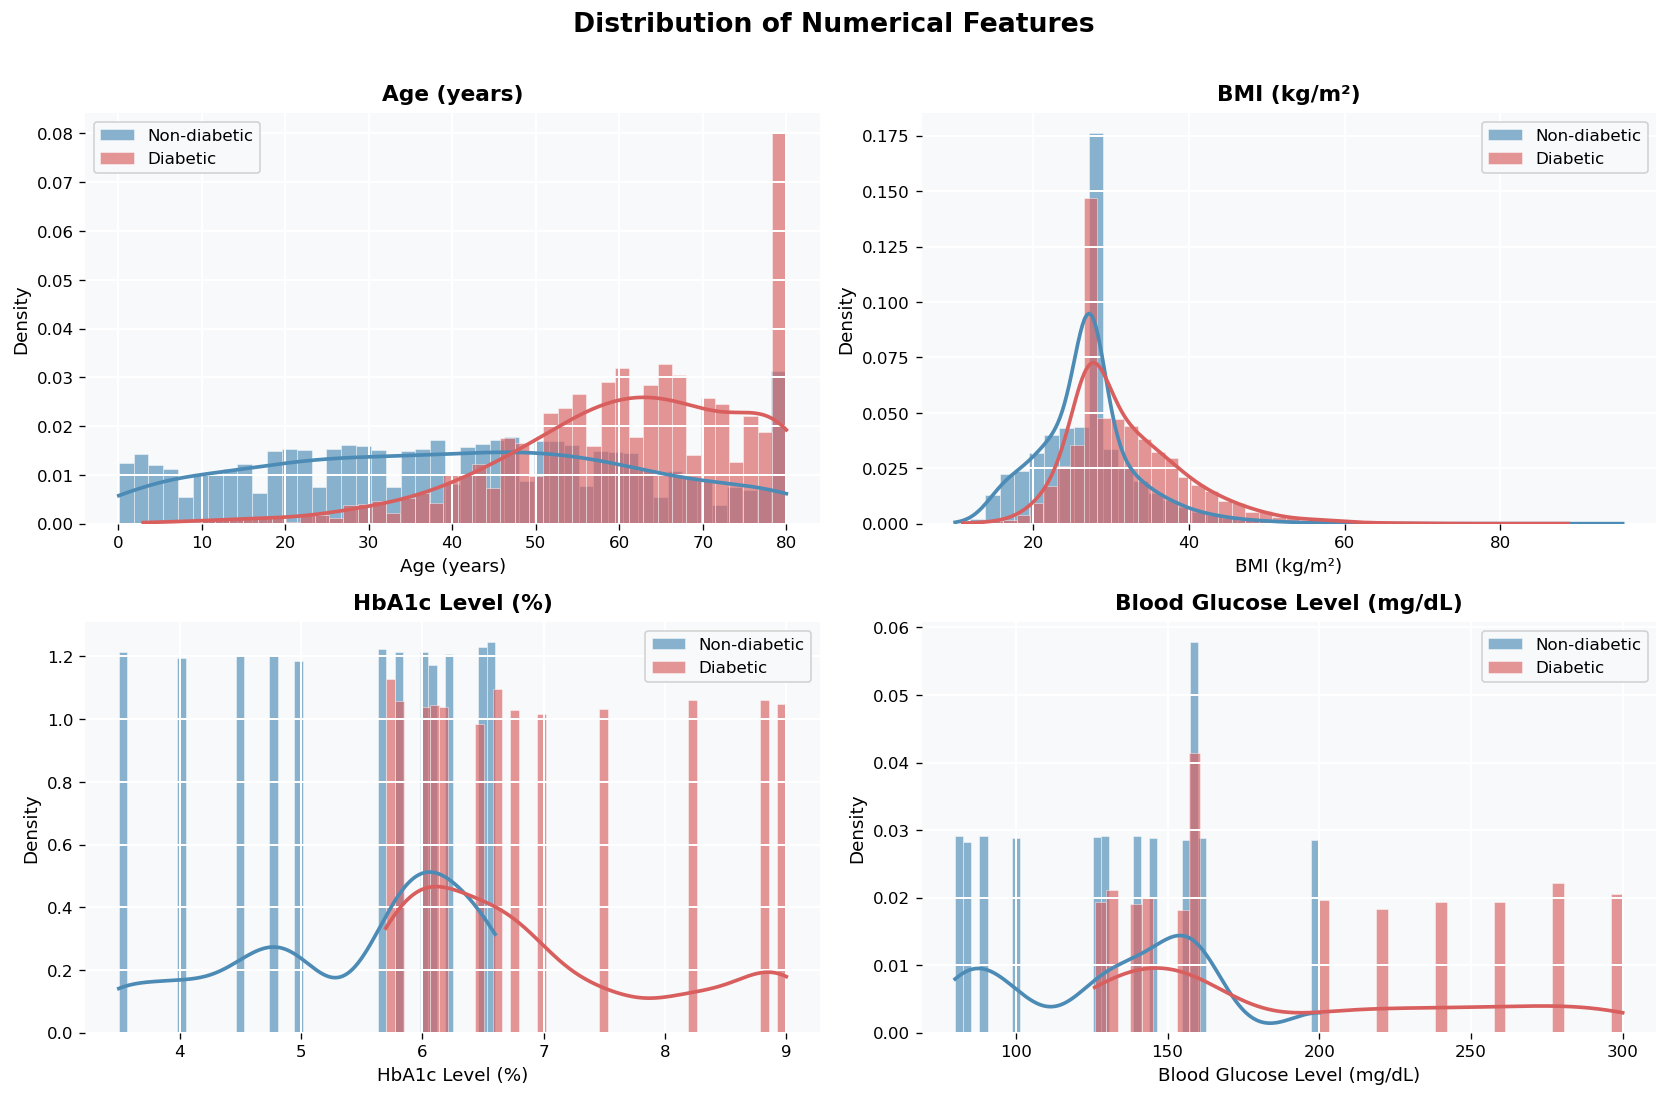

Saved: eda_histograms.png


In [5]:
#  Numerical Distributions
# Methodology: Visualise the shape, spread and skewness of each numerical feature.

numerical_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
labels         = ["Age (years)", "BMI (kg/m²)", "HbA1c Level (%)", "Blood Glucose Level (mg/dL)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribution of Numerical Features", fontsize=16, fontweight="bold", y=1.01)

for ax, col, label in zip(axes.flatten(), numerical_cols, labels):
    # Split by class
    d0 = df_raw.loc[df_raw["diabetes"] == 0, col].dropna()
    d1 = df_raw.loc[df_raw["diabetes"] == 1, col].dropna()

    ax.hist(d0, bins=45, color=C_BLUE,   alpha=0.65, density=True,
            label="Non-diabetic", edgecolor="white", linewidth=0.4)
    ax.hist(d1, bins=45, color=C_RED,    alpha=0.65, density=True,
            label="Diabetic",     edgecolor="white", linewidth=0.4)

    # KDE overlays
    from scipy.stats import gaussian_kde
    for data, color in [(d0, C_BLUE), (d1, C_RED)]:
        kde = gaussian_kde(data, bw_method=0.3)
        xs  = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, kde(xs), color=color, lw=2.2)

    ax.set_title(label, fontweight="bold", pad=8)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(framealpha=0.85)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_histograms.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: eda_histograms.png")

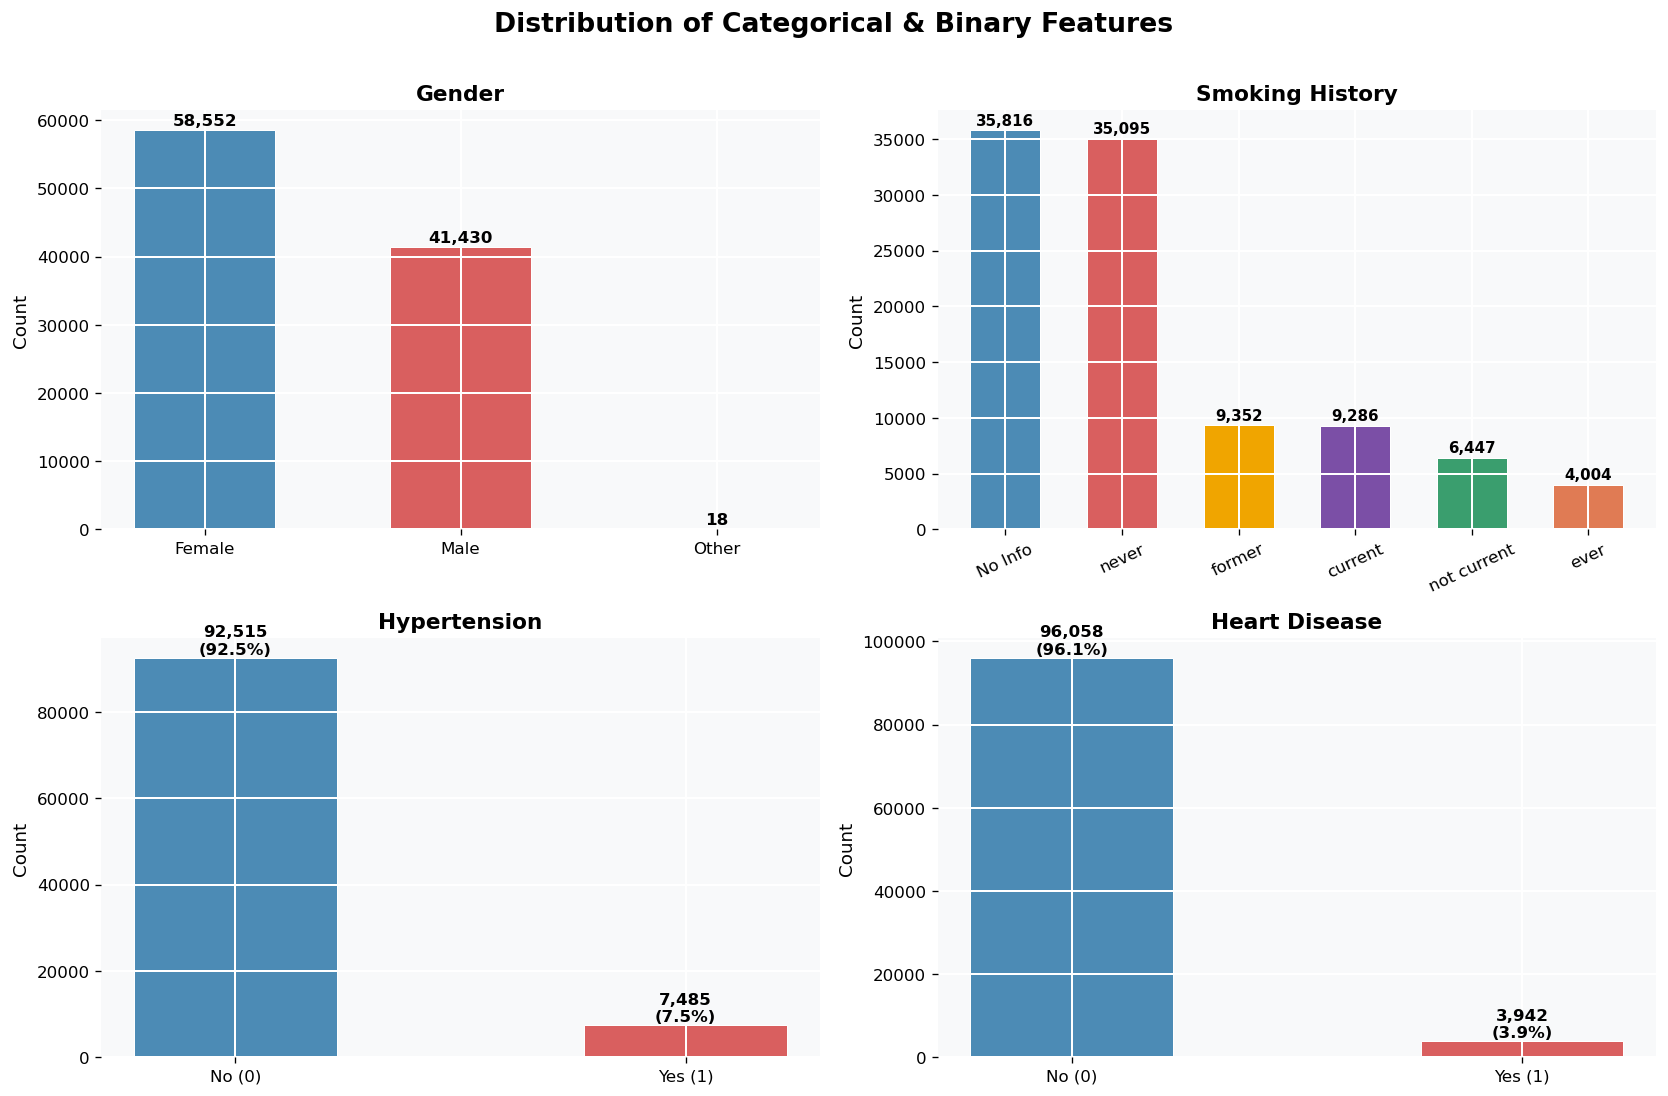

Saved: eda_countplots.png


In [6]:
# Categorical & Binary Variable Distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribution of Categorical & Binary Features",
             fontsize=16, fontweight="bold", y=1.01)

# ── Gender 
ax = axes[0, 0]
gender_counts = df_raw["gender"].value_counts()
bars = ax.bar(gender_counts.index, gender_counts.values,
              color=[C_BLUE, C_RED, C_PURPLE], edgecolor="white", linewidth=0.6,
              width=0.55)
for bar, val in zip(bars, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Gender", fontweight="bold")
ax.set_ylabel("Count")

# ── Smoking History 
ax = axes[0, 1]
smoke_counts = df_raw["smoking_history"].value_counts()
colors_smoke = [C_BLUE, C_RED, C_GOLD, C_PURPLE, C_GREEN, "#E07B54"]
bars = ax.bar(smoke_counts.index, smoke_counts.values,
              color=colors_smoke[:len(smoke_counts)],
              edgecolor="white", linewidth=0.6, width=0.6)
for bar, val in zip(bars, smoke_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Smoking History", fontweight="bold")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=25)

# ── Hypertension 
ax = axes[1, 0]
hyp_counts = df_raw["hypertension"].value_counts().sort_index()
bars = ax.bar(["No (0)", "Yes (1)"], hyp_counts.values,
              color=[C_BLUE, C_RED], edgecolor="white", linewidth=0.6, width=0.45)
for bar, val in zip(bars, hyp_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}\n({val/len(df_raw)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Hypertension", fontweight="bold")
ax.set_ylabel("Count")

# ── Heart Disease 
ax = axes[1, 1]
hd_counts = df_raw["heart_disease"].value_counts().sort_index()
bars = ax.bar(["No (0)", "Yes (1)"], hd_counts.values,
              color=[C_BLUE, C_RED], edgecolor="white", linewidth=0.6, width=0.45)
for bar, val in zip(bars, hd_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}\n({val/len(df_raw)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Heart Disease", fontweight="bold")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_countplots.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: eda_countplots.png")

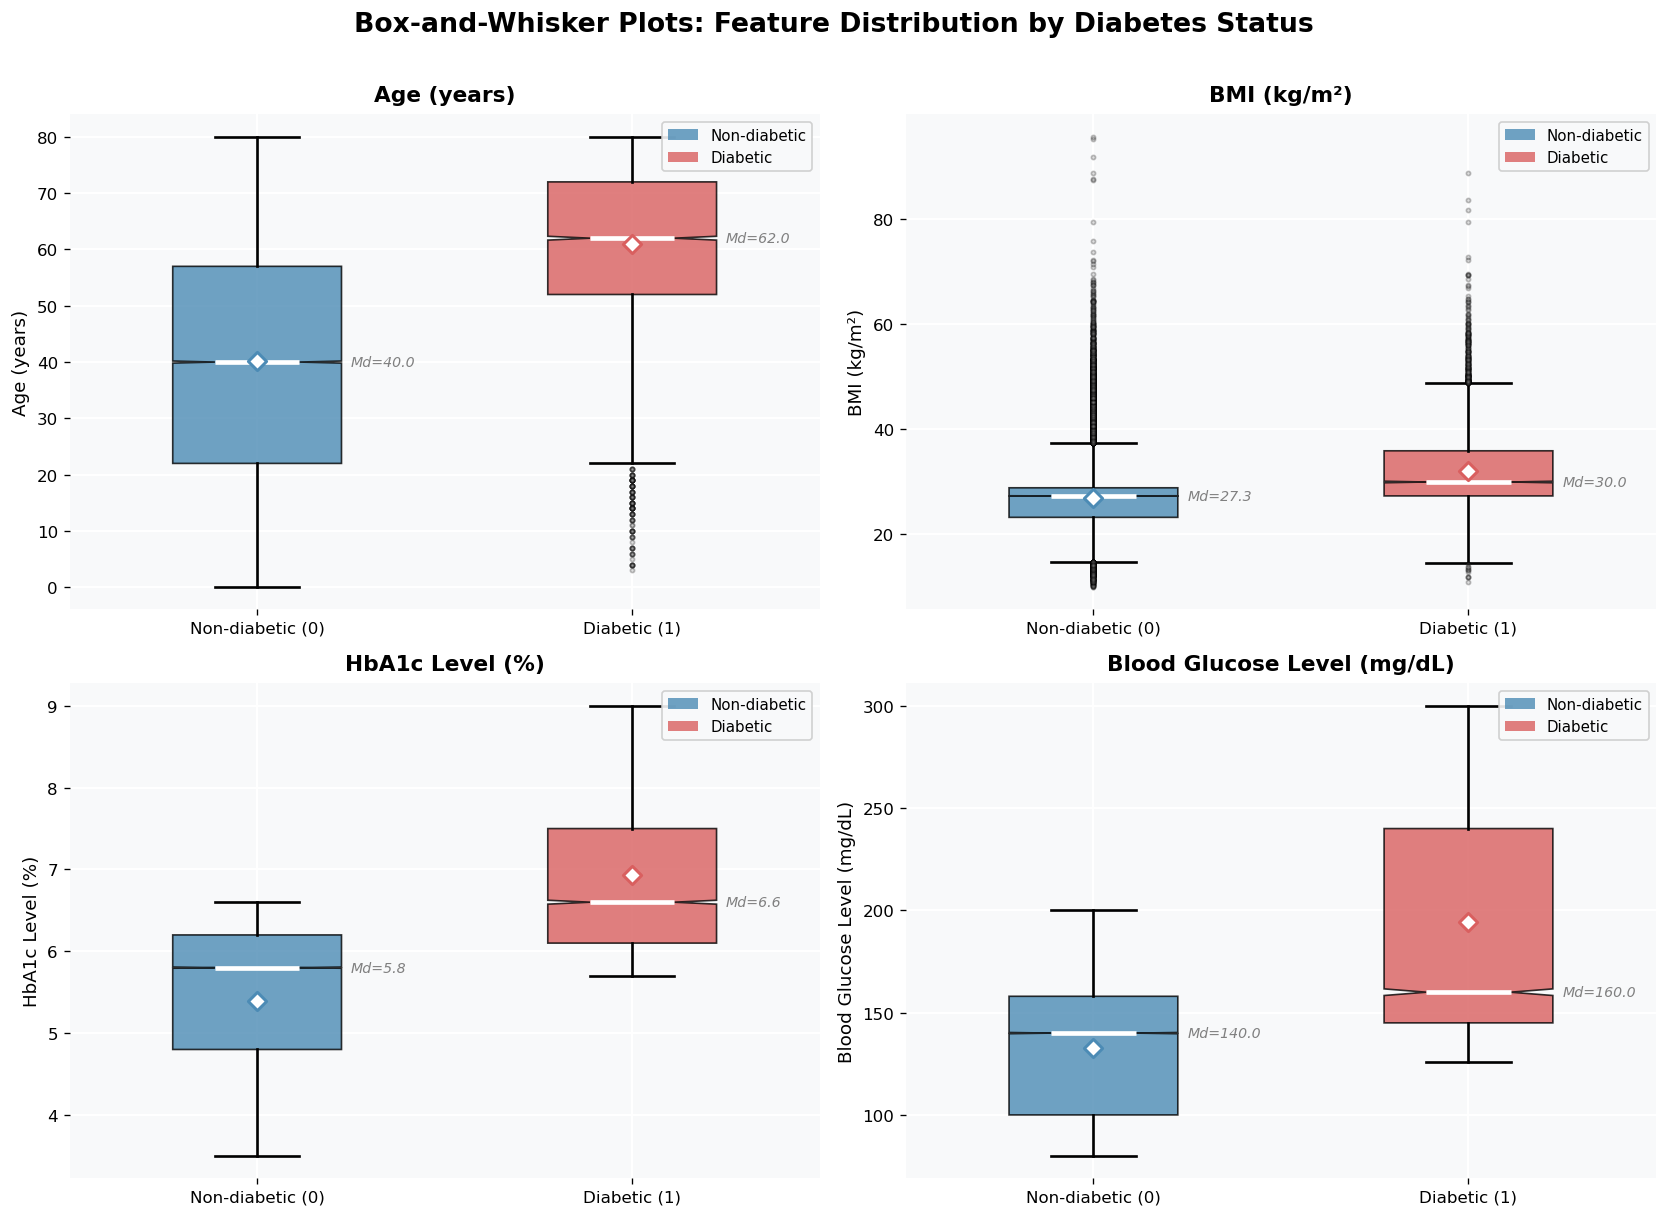

Saved: eda_boxplots.png


In [7]:
#  Box-and-Whisker Plots — Feature Distribution per Outcome Class
# Methodology: Inspect how each numerical feature varies across diabetes classes.
#              Reveals medians, IQR, and outlier presence per class.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Box-and-Whisker Plots: Feature Distribution by Diabetes Status",
             fontsize=16, fontweight="bold", y=1.01)

labels_map     = {0: "Non-diabetic", 1: "Diabetic"}
col_labels     = {
    "age":                 "Age (years)",
    "bmi":                 "BMI (kg/m²)",
    "HbA1c_level":        "HbA1c Level (%)",
    "blood_glucose_level": "Blood Glucose Level (mg/dL)"
}

for ax, col in zip(axes.flatten(), numerical_cols):
    data_by_class = [
        df_raw.loc[df_raw["diabetes"] == 0, col].dropna().values,
        df_raw.loc[df_raw["diabetes"] == 1, col].dropna().values,
    ]

    bp = ax.boxplot(
        data_by_class,
        positions=[1, 2],
        widths=0.45,
        patch_artist=True,
        notch=True,
        showfliers=True,
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markersize=2.5, alpha=0.25, linestyle="none"),
        medianprops=dict(color="white", linewidth=2.8),
        whiskerprops=dict(linewidth=1.6),
        capprops=dict(linewidth=1.6),
    )

    colors_bp = [C_BLUE, C_RED]
    for patch, color in zip(bp["boxes"], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.80)

    # Overlay individual mean markers
    for i, (data, color) in enumerate(zip(data_by_class, colors_bp), start=1):
        ax.scatter(i, np.mean(data), marker="D", color="white",
                   edgecolors=color, s=60, zorder=5, linewidths=1.8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non-diabetic (0)", "Diabetic (1)"], fontsize=10)
    ax.set_title(col_labels[col], fontweight="bold", pad=8)
    ax.set_ylabel(col_labels[col])

    # Annotate medians
    for i, data in enumerate(data_by_class, start=1):
        med = np.median(data)
        ax.text(i + 0.25, med, f"Md={med:.1f}", va="center",
                fontsize=8.5, color="gray", style="italic")

    # Legend
    patches = [
        mpatches.Patch(facecolor=C_BLUE, alpha=0.8, label="Non-diabetic"),
        mpatches.Patch(facecolor=C_RED,  alpha=0.8, label="Diabetic"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: eda_boxplots.png")

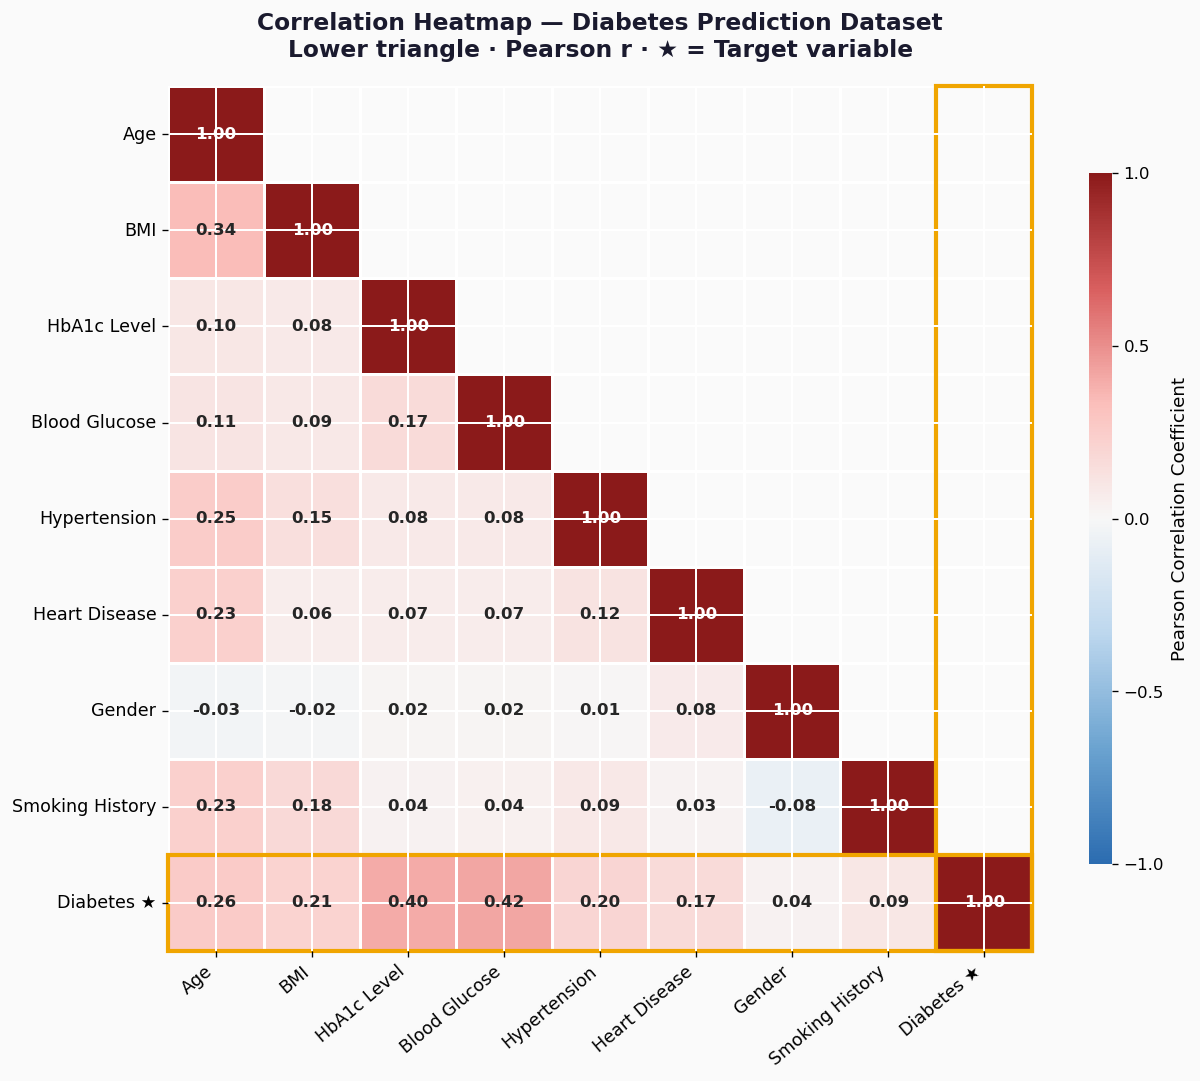

Saved: eda_correlation_heatmap.png

Top correlations with Diabetes (|r| ranked):
  blood_glucose_level   : r = +0.420  (|r| = 0.420)
  HbA1c_level           : r = +0.401  (|r| = 0.401)
  age                   : r = +0.258  (|r| = 0.258)
  bmi                   : r = +0.214  (|r| = 0.214)
  hypertension          : r = +0.198  (|r| = 0.198)
  heart_disease         : r = +0.172  (|r| = 0.172)
  smoking_enc           : r = +0.094  (|r| = 0.094)
  gender_enc            : r = +0.037  (|r| = 0.037)


In [8]:
# Correlation Heatmap
# Methodology: Encode all features numerically and visualise Pearson correlation
#              to identify multicollinearity and feature-target relationships.

df_corr = df_raw.copy()
df_corr["gender_enc"]       = LabelEncoder().fit_transform(df_corr["gender"])
df_corr["smoking_enc"]      = LabelEncoder().fit_transform(df_corr["smoking_history"])

corr_cols = [
    "age", "bmi", "HbA1c_level", "blood_glucose_level",
    "hypertension", "heart_disease",
    "gender_enc", "smoking_enc", "diabetes"
]
corr_labels = [
    "Age", "BMI", "HbA1c Level", "Blood Glucose",
    "Hypertension", "Heart Disease",
    "Gender", "Smoking History", "Diabetes ★"
]

corr_matrix = df_corr[corr_cols].corr()

# Custom diverging colormap: deep blue → white → deep red
cmap = LinearSegmentedColormap.from_list(
    "custom_div",
    ["#2B6CB0", "#6BA3D0", "#BDD7EE", "#F7F7F7",
     "#FBBFBB", "#D95F5F", "#8B1A1A"],
    N=256
)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # upper triangle only

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1, vmax=1,
    linewidths=1.5,
    linecolor="white",
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.8, "aspect": 30,
               "label": "Pearson Correlation Coefficient",
               "ticks": [-1, -0.5, 0, 0.5, 1]},
    ax=ax,
    square=True,
)

ax.set_xticklabels(corr_labels, rotation=40, ha="right", fontsize=10.5)
ax.set_yticklabels(corr_labels, rotation=0,  ha="right", fontsize=10.5)

# Highlight the diabetes row/column
n = len(corr_cols)
ax.add_patch(plt.Rectangle((0, n-1), n,   1,   fill=False,
                             edgecolor=C_GOLD, lw=2.5, clip_on=False))
ax.add_patch(plt.Rectangle((n-1, 0), 1,   n,   fill=False,
                             edgecolor=C_GOLD, lw=2.5, clip_on=False))

ax.set_title(
    "Correlation Heatmap — Diabetes Prediction Dataset\n"
    "Lower triangle · Pearson r · ★ = Target variable",
    fontsize=14, fontweight="bold", pad=18, color="#1A1A2E"
)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_correlation_heatmap.png",
            dpi=200, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: eda_correlation_heatmap.png")

# Print strongest correlations with target
print("\nTop correlations with Diabetes (|r| ranked):")
target_corr = corr_matrix["diabetes"].drop("diabetes").abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    raw_r = corr_matrix["diabetes"][feat]
    print(f"  {feat:<22}: r = {raw_r:+.3f}  (|r| = {val:.3f})")

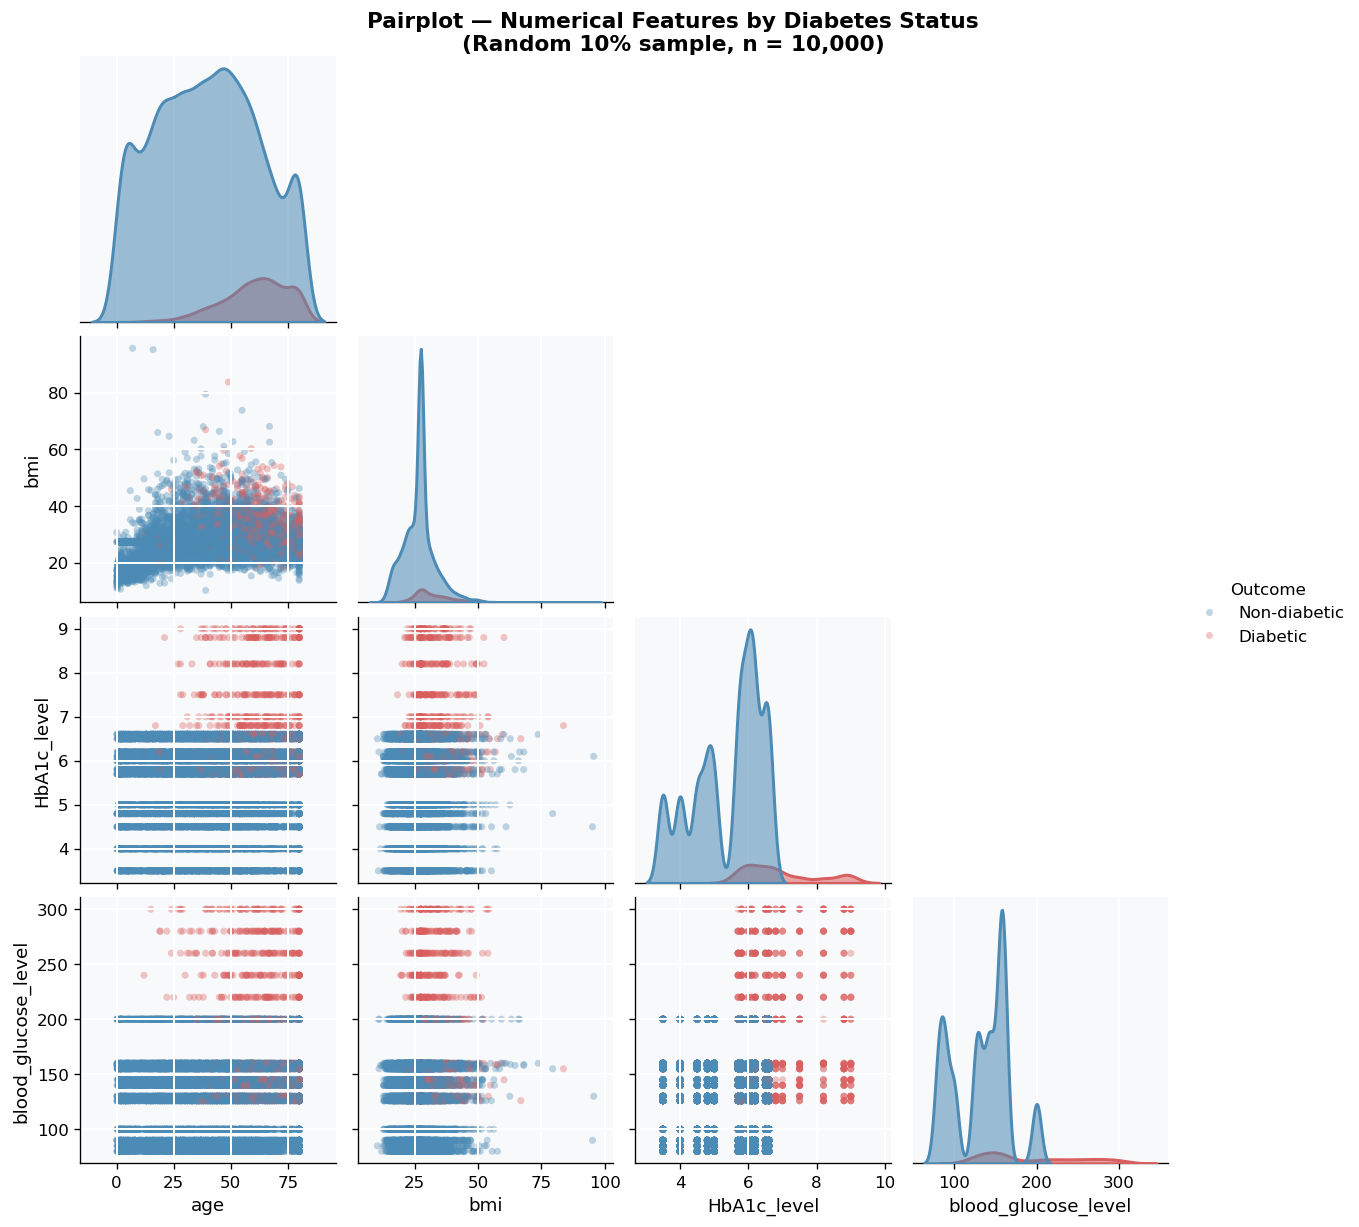

Saved: eda_pairplot.png


In [9]:
# Pairplot for Numerical Features
# Methodology: Reveals pairwise relationships and class separability.
# Note: Plotted on a 10% random sample for speed; set PAIRPLOT_FRAC=1.0 for full data.

PAIRPLOT_FRAC = 0.10
df_pair = df_raw[numerical_cols + ["diabetes"]].sample(
    frac=PAIRPLOT_FRAC, random_state=RANDOM_STATE
).copy()
df_pair["Outcome"] = df_pair["diabetes"].map({0: "Non-diabetic", 1: "Diabetic"})

palette_pp = {"Non-diabetic": C_BLUE, "Diabetic": C_RED}

g = sns.pairplot(
    df_pair,
    vars=numerical_cols,
    hue="Outcome",
    palette=palette_pp,
    diag_kind="kde",
    plot_kws={"alpha": 0.35, "s": 18, "edgecolors": "none"},
    diag_kws={"fill": True, "alpha": 0.55, "linewidth": 1.8},
    corner=True,
)
g.figure.suptitle(
    f"Pairplot — Numerical Features by Diabetes Status\n"
    f"(Random {int(PAIRPLOT_FRAC*100)}% sample, n = {len(df_pair):,})",
    y=1.02, fontsize=13, fontweight="bold"
)
g._legend.set_title("Outcome")

plt.savefig(f"{OUT_DIR}/eda_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_pairplot.png")

In [10]:
#  Outlier Detection (IQR & Z-Score)
# Methodology: Both methods applied to identify extent of outlier contamination
#              before Winsorization is applied in the preprocessing pipeline.

print("=" * 65)
print("  OUTLIER DETECTION REPORT")
print("=" * 65)
print(f"\n{'Feature':<25} {'IQR Outliers':>13} {'Z>3 Outliers':>13} {'IQR Lower':>10} {'IQR Upper':>10}")
print("-" * 65)

outlier_summary = {}
for col in numerical_cols:
    Q1, Q3    = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR       = Q3 - Q1
    lo, hi    = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_iqr     = ((df_raw[col] < lo) | (df_raw[col] > hi)).sum()
    z_scores  = np.abs(stats.zscore(df_raw[col].dropna()))
    n_z       = (z_scores > 3).sum()
    outlier_summary[col] = {"IQR": n_iqr, "Z>3": n_z, "lower": lo, "upper": hi}
    print(f"  {col:<23} {n_iqr:>13,} {n_z:>13,} {lo:>10.2f} {hi:>10.2f}")

print("-" * 65)
print("\n→ Winsorization (clip at 1st/99th percentile) will be applied")
print("  inside the preprocessing pipeline to limit extreme values.")

  OUTLIER DETECTION REPORT

Feature                    IQR Outliers  Z>3 Outliers  IQR Lower  IQR Upper
-----------------------------------------------------------------
  age                                 0             0     -30.00     114.00
  bmi                             7,086         1,294      14.71      38.50
  HbA1c_level                     1,315         1,315       2.70       8.30
  blood_glucose_level             2,038         1,403      11.50     247.50
-----------------------------------------------------------------

→ Winsorization (clip at 1st/99th percentile) will be applied
  inside the preprocessing pipeline to limit extreme values.


In [11]:
# Data Cleaning & Preprocessing
# Methodology: Remove duplicates, define column groups, apply Winsorization,
#              then define ColumnTransformer (fitted ONLY on training data).

df = df_raw.copy()
# Remove duplicate records 
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed : {before - len(df):,}  |  Remaining rows: {len(df):,}")

# Column definitions 
num_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level",
            "hypertension", "heart_disease"]
cat_cols = ["gender", "smoking_history"]

#  Winsorization — clip at 1st / 99th percentile 
#   Applied only to continuous columns to cap extreme values.
for col in ["age", "bmi", "HbA1c_level", "blood_glucose_level"]:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lo, upper=hi)
print("Winsorization applied (1st–99th percentile) to continuous columns.")

#   Define X and y 
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Features: {X.columns.tolist()}")
print(f"\nClass distribution after cleaning:\n{y.value_counts()}")

# ColumnTransformer — StandardScaler + One-Hot Encoding 
#   IMPORTANT: this transformer is defined here but fitted ONLY on training data.
def make_preprocessor():
    """Return a fresh, unfitted ColumnTransformer for use inside a pipeline."""
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ])

print("\n Preprocessing setup complete.")

Duplicates removed : 3,854  |  Remaining rows: 96,146
Winsorization applied (1st–99th percentile) to continuous columns.

X shape : (96146, 8)
y shape : (96146,)
Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Class distribution after cleaning:
diabetes
0    87664
1     8482
Name: count, dtype: int64

 Preprocessing setup complete.


In [12]:
# Train-Test Split (80/20, stratified)
# Methodology: Stratified split ensures both sets reflect original class proportions.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = RANDOM_STATE
)

print("=" * 50)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 50)
print(f"  Training set   : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set       : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n  Train class distribution:")
for label, count in y_train.value_counts().sort_index().items():
    pct = count / len(y_train) * 100
    print(f"    Class {label}: {count:,}  ({pct:.1f}%)")
print(f"\n  Test class distribution:")
for label, count in y_test.value_counts().sort_index().items():
    pct = count / len(y_test) * 100
    print(f"    Class {label}: {count:,}  ({pct:.1f}%)")

  TRAIN-TEST SPLIT SUMMARY
  Training set   :  76,916 rows  (80.0%)
  Test set       :  19,230 rows  (20.0%)

  Train class distribution:
    Class 0: 70,130  (91.2%)
    Class 1: 6,786  (8.8%)

  Test class distribution:
    Class 0: 17,534  (91.2%)
    Class 1: 1,696  (8.8%)


In [13]:
# SMOTE: Handle Class Imbalance
# Methodology: SMOTE is applied ONLY on training data and is embedded inside
#              every ImbPipeline so it only sees training fold data during CV.
#              This cell demonstrates its effect for reporting purposes.

from imblearn.over_sampling import SMOTE

# Quick demonstration using a temporary preprocessor fit on train only
_demo_prep = make_preprocessor()
X_tr_demo  = _demo_prep.fit_transform(X_train)

sm          = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_tr_demo, y_train)

print("=" * 50)
print("  SMOTE DEMONSTRATION (training data only)")
print("=" * 50)
print(f"\n  BEFORE SMOTE:")
for label, count in y_train.value_counts().sort_index().items():
    print(f"    Class {label}: {count:,}")

print(f"\n  AFTER SMOTE:")
for label, count in pd.Series(y_res).value_counts().sort_index().items():
    print(f"    Class {label}: {count:,}")

print(f"\n  Synthetic minority samples added: "
      f"{(y_res == 1).sum() - (y_train == 1).sum():,}")
print("\n Note: This is for demonstration only.")
print("   SMOTE is embedded inside ImbPipeline and will automatically")
print("   run on each training fold during GridSearchCV — not on test data.")
del _demo_prep, X_tr_demo, X_res, y_res, sm

  SMOTE DEMONSTRATION (training data only)

  BEFORE SMOTE:
    Class 0: 70,130
    Class 1: 6,786

  AFTER SMOTE:
    Class 0: 70,130
    Class 1: 70,130

  Synthetic minority samples added: 63,344

 Note: This is for demonstration only.
   SMOTE is embedded inside ImbPipeline and will automatically
   run on each training fold during GridSearchCV — not on test data.


In [14]:
# Defining Machine Learning Pipelines
# Each pipeline chains: ColumnTransformer → SMOTE → Classifier.
#              Using imblearn.Pipeline ensures SMOTE only runs on training folds.

pipelines = {

    "Logistic Regression": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   LogisticRegression(
                      random_state = RANDOM_STATE,
                      max_iter     = 1000,
                      solver       = "lbfgs"
                  ))
    ]),

    "Random Forest": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   RandomForestClassifier(
                      random_state = RANDOM_STATE,
                      n_jobs       = -1
                  ))
    ]),

    "SVM": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   SVC(
                      kernel      = "rbf",
                      probability = True,
                      random_state= RANDOM_STATE
                  ))
    ]),

    "KNN": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   KNeighborsClassifier(n_jobs=-1))
    ]),

    "XGBoost": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   XGBClassifier(
                      random_state    = RANDOM_STATE,
                      eval_metric     = "logloss",
                      verbosity       = 0,
                      n_jobs          = -1
                  ))
    ]),

    "LightGBM": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   LGBMClassifier(
                      random_state = RANDOM_STATE,
                      verbose      = -1,
                      n_jobs       = -1
                  ))
    ]),

    "Neural Network": ImbPipeline([
        ("prep",  make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   MLPClassifier(
                      random_state       = RANDOM_STATE,
                      max_iter           = 500,
                      early_stopping     = True,
                      validation_fraction= 0.1
                  ))
    ]),
}

print("Pipelines defined for all 7 classifiers:")
for name in pipelines:
    print(f"   • {name}")

Pipelines defined for all 7 classifiers:
   • Logistic Regression
   • Random Forest
   • SVM
   • KNN
   • XGBoost
   • LightGBM
   • Neural Network


In [15]:
# Hyperparameter Tuning: GridSearchCV with StratifiedKFold-5
# Methodology: scoring='roc_auc' prioritises discriminative ability.
#              StratifiedKFold preserves class proportions across folds.
#              IMPORTANT: SVM and Neural Network are trained on a 25,000-row
#              subsample due to their O(n²/n³) complexity on 100K records.
#              All other models use the full training set.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Logistic Regression": {
        "clf__C":      [0.01, 0.1, 1.0, 10.0],
        "clf__solver": ["lbfgs"],
    },
    "Random Forest": {
        "clf__n_estimators":   [100, 200],
        "clf__max_depth":      [None, 10, 20],
        "clf__min_samples_split": [2, 5],
    },
    "SVM": {
        "clf__C":     [0.1, 1.0, 10.0],
        "clf__gamma": ["scale", "auto"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 11, 21],
        "clf__metric":      ["euclidean", "manhattan"],
    },
    "XGBoost": {
        "clf__n_estimators":  [100, 200],
        "clf__max_depth":     [3, 5, 7],
        "clf__learning_rate": [0.05, 0.1, 0.2],
    },
    "LightGBM": {
        "clf__n_estimators":  [100, 200],
        "clf__num_leaves":    [31, 63, 127],
        "clf__learning_rate": [0.05, 0.1],
    },
    "Neural Network": {
        "clf__hidden_layer_sizes": [(64, 32), (128, 64), (256, 128, 64)],
        "clf__activation":         ["relu", "tanh"],
        "clf__alpha":              [0.0001, 0.001],
    },
}

# Models fitted on a subsample to manage training time
SUBSAMPLE_MODELS = {"SVM", "Neural Network"}
SUBSAMPLE_SIZE   = 25_000     # rows from training set

best_estimators  = {}
tuning_results   = {}

print("GridSearchCV Tuning — StratifiedKFold(5) — scoring: ROC-AUC\n")
print(f"{'Model':<22} {'Best CV AUC':>12}  Best Parameters")
print("-" * 80)

for name, pipeline in pipelines.items():
    if name in SUBSAMPLE_MODELS:
        idx    = X_train.sample(n=SUBSAMPLE_SIZE, random_state=RANDOM_STATE).index
        Xf, yf = X_train.loc[idx], y_train.loc[idx]
        note   = f"(25K subsample)"
    else:
        Xf, yf = X_train, y_train
        note   = ""

    gs = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grids[name],
        cv         = cv,
        scoring    = "roc_auc",
        n_jobs     = -1,
        refit      = True,
        verbose    = 0,
    )
    gs.fit(Xf, yf)
    best_estimators[name] = gs.best_estimator_
    tuning_results[name]  = {
        "best_params":  gs.best_params_,
        "cv_roc_auc":   round(gs.best_score_, 4),
    }
    print(f"  {name:<20} {gs.best_score_:>12.4f}  {gs.best_params_}  {note}")

print("\n All models tuned and stored in best_estimators.")

GridSearchCV Tuning — StratifiedKFold(5) — scoring: ROC-AUC

Model                   Best CV AUC  Best Parameters
--------------------------------------------------------------------------------
  Logistic Regression        0.9623  {'clf__C': 0.01, 'clf__solver': 'lbfgs'}  
  Random Forest              0.9721  {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}  
  SVM                        0.9611  {'clf__C': 10.0, 'clf__gamma': 'auto'}  (25K subsample)
  KNN                        0.9542  {'clf__metric': 'euclidean', 'clf__n_neighbors': 21}  
  XGBoost                    0.9780  {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}  
  LightGBM                   0.9780  {'clf__learning_rate': 0.05, 'clf__n_estimators': 100, 'clf__num_leaves': 31}  
  Neural Network             0.9652  {'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32)}  (25K subsample)

 All models tuned and stored in best_estimators.


In [16]:
# Model Evaluation on Hold-Out Test Set
def specificity_score(y_true, y_pred):
    """Specificity = TN / (TN + FP)."""
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

results  = {}
y_preds  = {}
y_probas = {}

for name, est in best_estimators.items():
    y_pred   = est.predict(X_test)
    y_proba  = est.predict_proba(X_test)[:, 1]
    y_preds[name]  = y_pred
    y_probas[name] = y_proba

    results[name] = {
        "Accuracy":             round(accuracy_score(y_test, y_pred), 4),
        "Precision":            round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall (Sensitivity)": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "Specificity":          round(specificity_score(y_test, y_pred), 4),
        "F1-Score":             round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC":              round(roc_auc_score(y_test, y_proba), 4),
    }

    print(f"\n{'─'*54}")
    print(f"  {name}")
    print(f"{'─'*54}")
    for metric, val in results[name].items():
        print(f"  {metric:<26}: {val:.4f}")
    print(f"\n  Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\n  Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Non-diabetic", "Diabetic"],
        digits=4
    ))


──────────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────────
  Accuracy                  : 0.8842
  Precision                 : 0.4245
  Recall (Sensitivity)      : 0.8779
  Specificity               : 0.8849
  F1-Score                  : 0.5723
  ROC-AUC                   : 0.9600

  Confusion Matrix:
[[15515  2019]
 [  207  1489]]

  Classification Report:
              precision    recall  f1-score   support

Non-diabetic     0.9868    0.8849    0.9331     17534
    Diabetic     0.4245    0.8779    0.5723      1696

    accuracy                         0.8842     19230
   macro avg     0.7056    0.8814    0.7527     19230
weighted avg     0.9372    0.8842    0.9012     19230


──────────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────────
  Accuracy                  : 0.9080
  Precision                 : 0.4880
  Recall (Sensitivity)      : 0.8721
  

In [17]:
# Final Comparison Table (all models, all metrics)
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("ROC-AUC", ascending=False)
)
results_df.index.name = "Model"

# Display with colour-coded highlighting
styled = (
    results_df.style
    .highlight_max(axis=0, color="#C6EFCE")   # green = best per column
    .highlight_min(axis=0, color="#FFCCCC")   # red   = worst per column
    .format("{:.4f}")
    .set_caption("📊 Model Comparison — All Metrics (sorted by ROC-AUC, ↑ = best)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#2B6CB0"), ("color", "white"),
                   ("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
)
display(styled)

# Save to CSV
results_df.to_csv(f"{OUT_DIR}/model_comparison_table.csv")
print("Saved: model_comparison_table.csv")

best_model_name = results_df["ROC-AUC"].idxmax()
best_auc        = results_df.loc[best_model_name, "ROC-AUC"]
print(f"\n★  Best model : {best_model_name}  (ROC-AUC = {best_auc:.4f})")

,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC
Model,,,,,,
XGBoost,0.9682,0.8934,0.7264,0.9916,0.8013,0.9761
LightGBM,0.9694,0.9242,0.7117,0.9944,0.8041,0.9758
Random Forest,0.9080,0.4880,0.8721,0.9115,0.6258,0.9708
SVM,0.8869,0.4313,0.8862,0.8870,0.5802,0.9614
Logistic Regression,0.8842,0.4245,0.8779,0.8849,0.5723,0.9600
Neural Network,0.9200,0.5304,0.8072,0.9309,0.6402,0.9592
KNN,0.8849,0.4253,0.8679,0.8866,0.5709,0.9497


Saved: model_comparison_table.csv

★  Best model : XGBoost  (ROC-AUC = 0.9761)


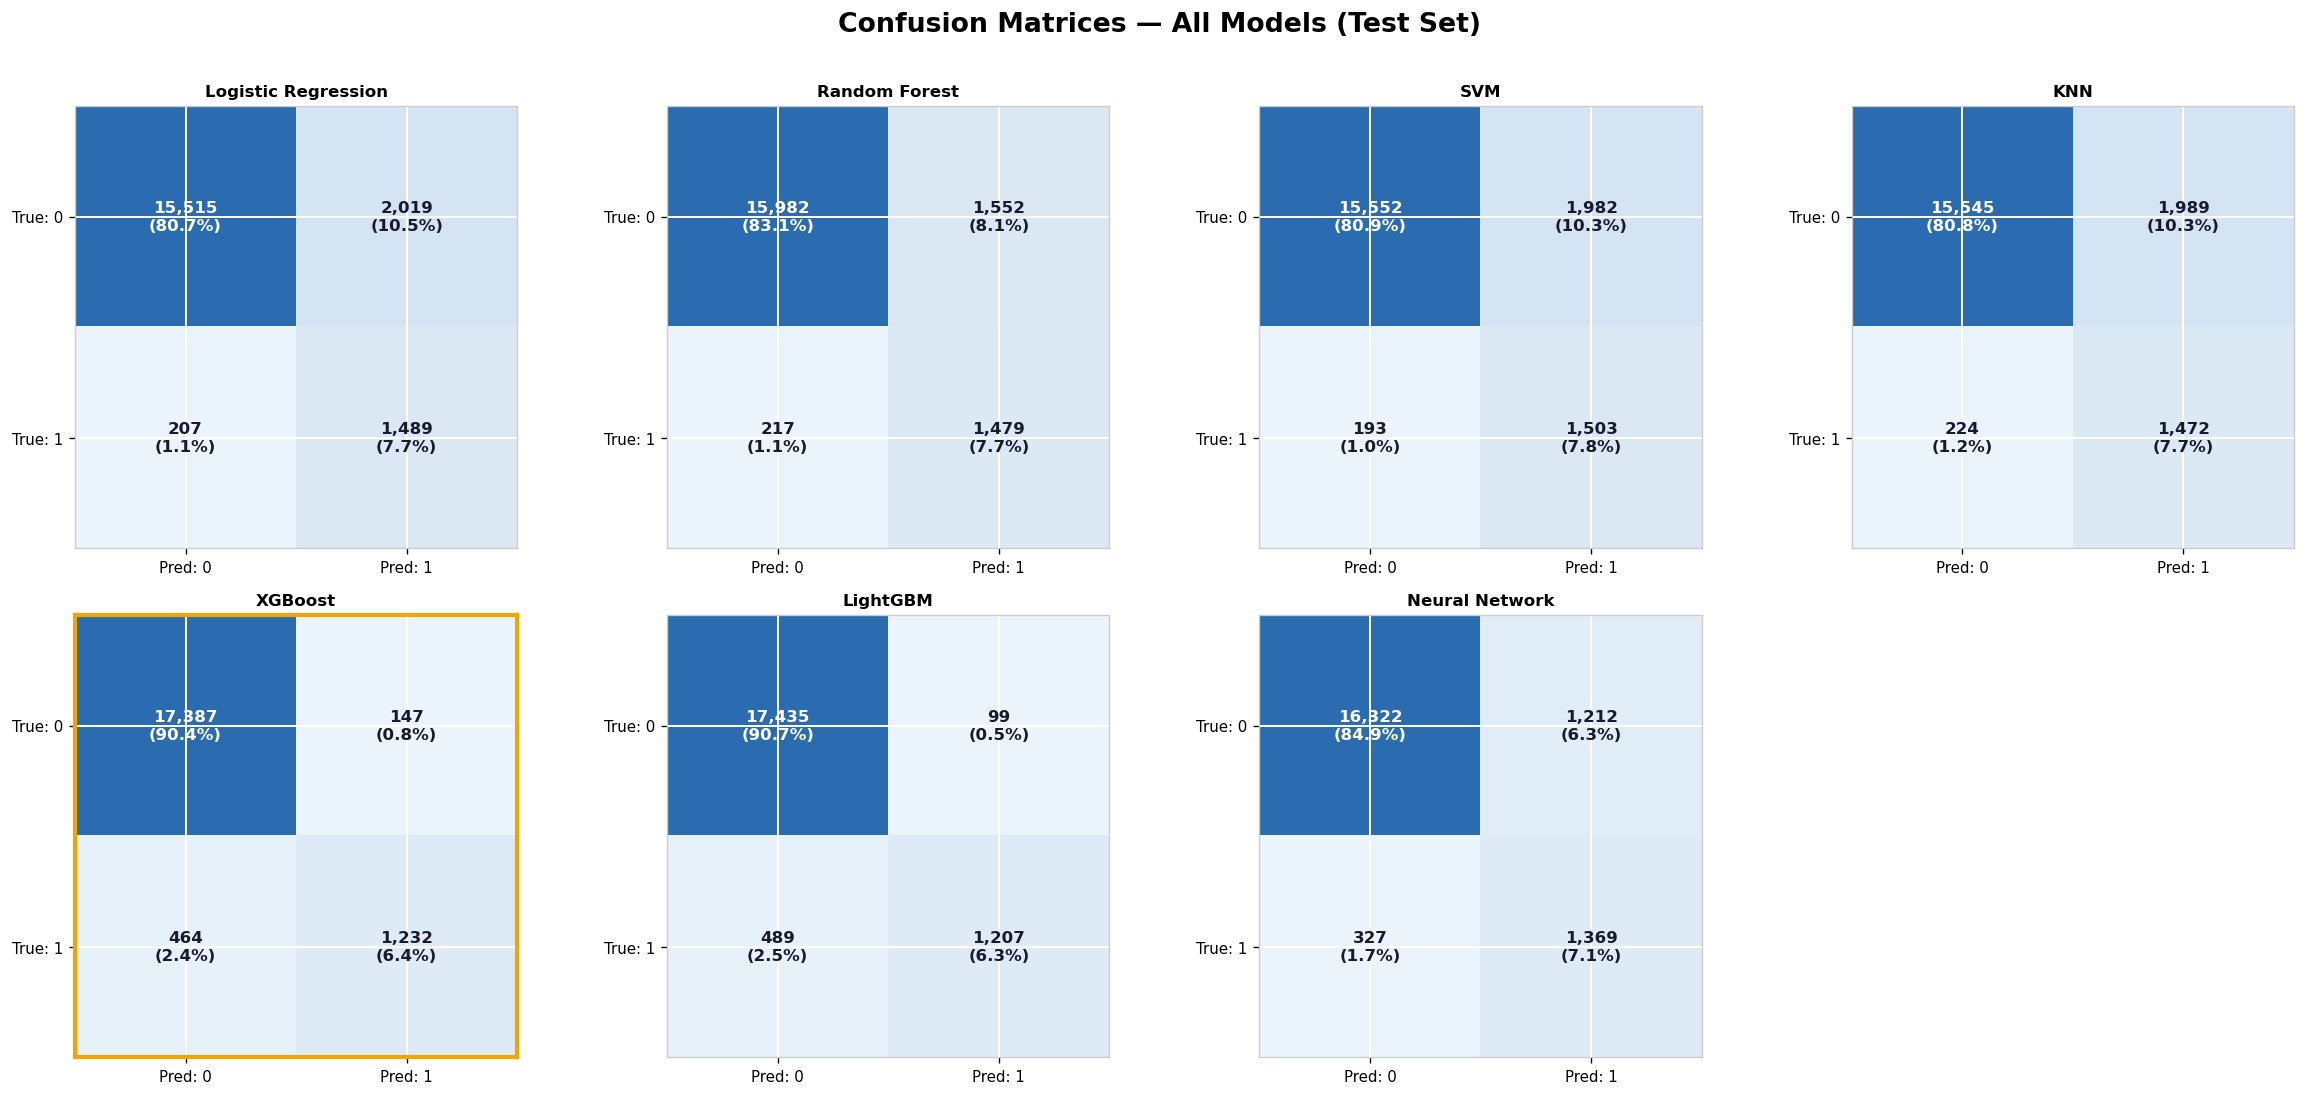

Saved: confusion_matrices_all.png


In [18]:
# Confusion Matrix Grid for All Models

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Confusion Matrices — All Models (Test Set)",
             fontsize=16, fontweight="bold", y=1.01)

model_names = list(best_estimators.keys())

for idx, name in enumerate(model_names):
    ax  = axes[idx // 4][idx % 4]
    cm  = confusion_matrix(y_test, y_preds[name])
    tn, fp, fn, tp = cm.ravel()
    total = cm.sum()

    # Heatmap
    im = ax.imshow(cm, interpolation="nearest",
                   cmap=LinearSegmentedColormap.from_list(
                       "cm_cmap", ["#EBF4FB", "#2B6CB0"], N=256))

    # Annotate cells
    for (r, c), val in np.ndenumerate(cm):
        pct = val / total * 100
        ax.text(c, r, f"{val:,}\n({pct:.1f}%)",
                ha="center", va="center", fontsize=10,
                color="white" if val > cm.max() / 2 else "#1A1A2E",
                fontweight="bold")

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: 0", "Pred: 1"], fontsize=9)
    ax.set_yticklabels(["True: 0", "True: 1"], fontsize=9)
    ax.set_title(name, fontweight="bold", fontsize=10, pad=6)

    # Color border gold if best model
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(C_GOLD if name == best_model_name else "#CCCCCC")
        spine.set_linewidth(2.5 if name == best_model_name else 0.8)

# Hide unused subplot (7 models, 8 slots)
axes[1][3].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrices_all.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_all.png")

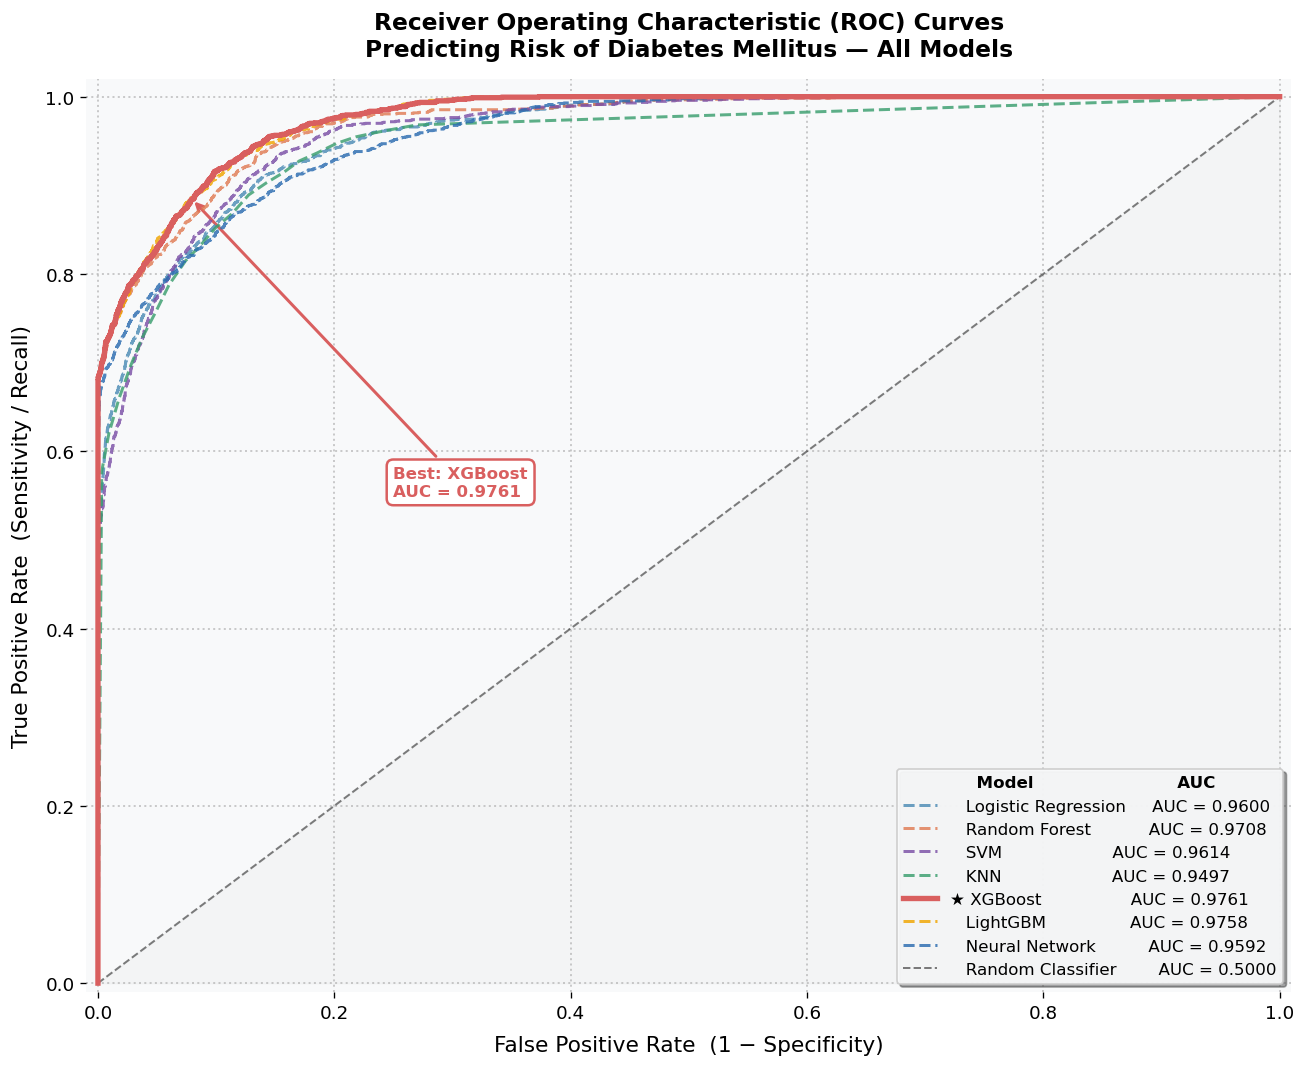

Saved: roc_curves_all_models.png


In [19]:
# ROC-AUC Curves: All Models on One Publication-Quality Figure
# Methodology: ROC curves compare true positive rate vs false positive rate
#              across all probability thresholds. AUC summarises overall performance.

MODEL_COLORS = {
    "Logistic Regression": "#4C8BB5",
    "Random Forest":       "#E07B54",
    "SVM":                 "#7B4FA6",
    "KNN":                 "#3A9E6E",
    "XGBoost":             "#D95F5F",
    "LightGBM":            "#F0A500",
    "Neural Network":      "#2B6CB0",
}

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")

for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    auc_val     = results[name]["ROC-AUC"]
    is_best     = (name == best_model_name)
    ax.plot(
        fpr, tpr,
        lw        = 3.2 if is_best else 1.8,
        linestyle = "-"  if is_best else "--",
        color     = MODEL_COLORS[name],
        alpha     = 1.0  if is_best else 0.82,
        label     = f"{'★ ' if is_best else '   '}{name:<22}  AUC = {auc_val:.4f}",
        zorder    = 10   if is_best else 5,
    )

# Reference diagonal
ax.fill_between([0, 1], [0, 1], alpha=0.04, color="grey")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="   Random Classifier        AUC = 0.5000")

# Formatting
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.02])
ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=13, labelpad=8)
ax.set_ylabel("True Positive Rate  (Sensitivity / Recall)", fontsize=13, labelpad=8)
ax.set_title(
    "Receiver Operating Characteristic (ROC) Curves\n"
    "Predicting Risk of Diabetes Mellitus — All Models",
    fontsize=14, fontweight="bold", pad=14
)

legend = ax.legend(
    loc="lower right", fontsize=10,
    framealpha=0.95, edgecolor="#CCCCCC",
    fancybox=True, shadow=True,
    title="  Model                         AUC",
    title_fontsize=10,
)
legend.get_title().set_fontweight("bold")

ax.grid(True, linestyle=":", alpha=0.6, color="#AAAAAA")
ax.tick_params(labelsize=11)

# Annotate best model AUC
best_fpr, best_tpr, _ = roc_curve(y_test, y_probas[best_model_name])
# Find point closest to (0.1, 0.9) for annotation
best_idx = np.argmin(np.abs(best_fpr - 0.08))
ax.annotate(
    f"Best: {best_model_name}\nAUC = {results[best_model_name]['ROC-AUC']:.4f}",
    xy        = (best_fpr[best_idx], best_tpr[best_idx]),
    xytext    = (0.25, 0.55),
    fontsize  = 10,
    fontweight= "bold",
    color     = MODEL_COLORS[best_model_name],
    arrowprops= dict(arrowstyle="->", color=MODEL_COLORS[best_model_name], lw=1.8),
    bbox      = dict(boxstyle="round,pad=0.4", fc="white",
                     ec=MODEL_COLORS[best_model_name], lw=1.5),
)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curves_all_models.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: roc_curves_all_models.png")

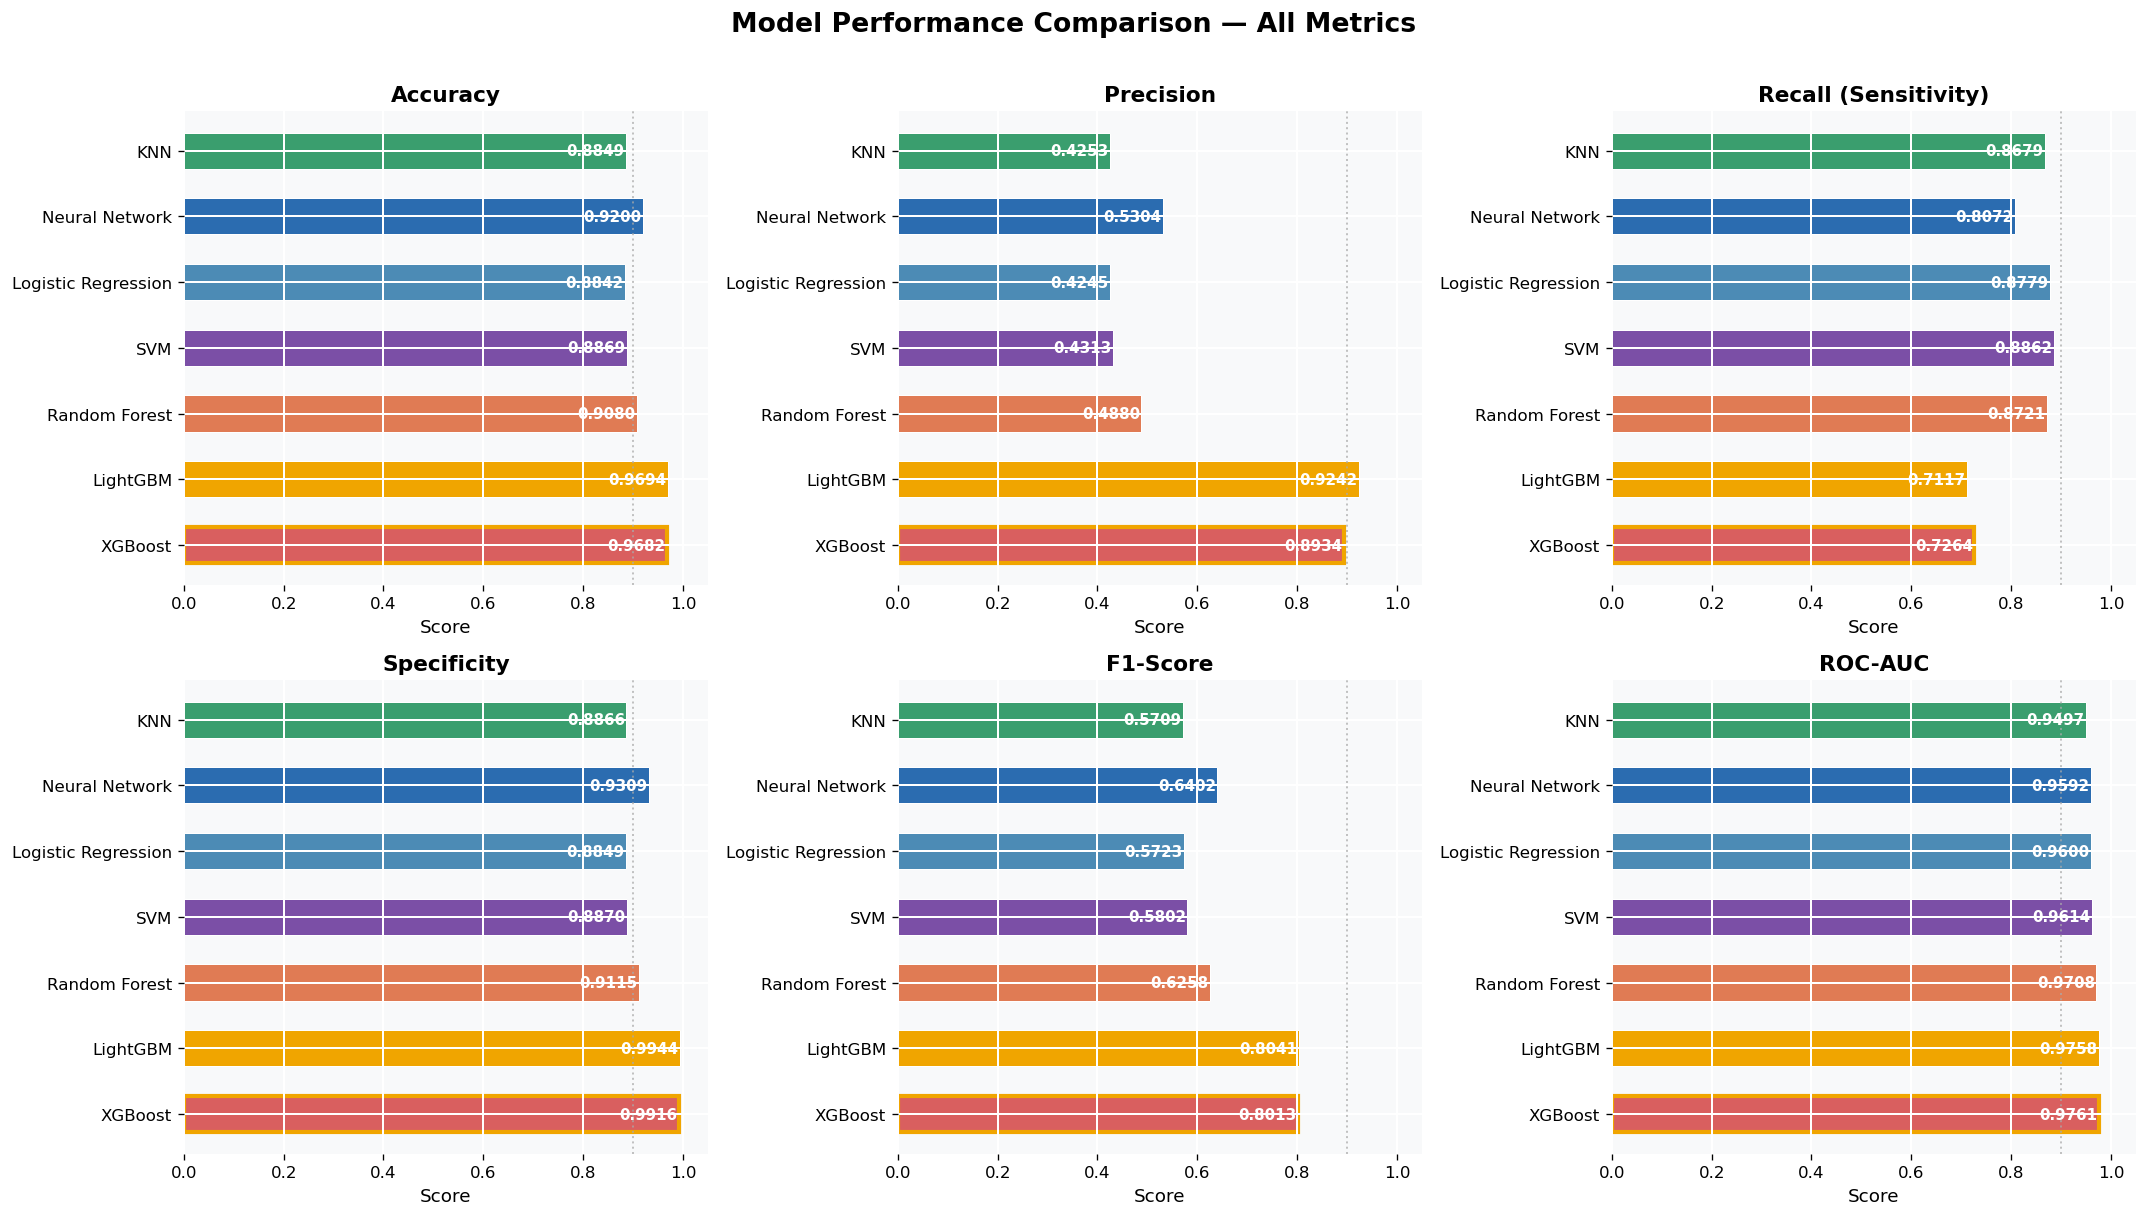

In [20]:
# Visual Comparison Across All Models

metrics_to_plot = ["Accuracy", "Precision", "Recall (Sensitivity)",
                   "Specificity", "F1-Score", "ROC-AUC"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Performance Comparison — All Metrics",
             fontsize=16, fontweight="bold", y=1.01)

bar_colors = [MODEL_COLORS[n] for n in results_df.index]

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    vals  = results_df[metric]
    bars  = ax.barh(results_df.index, vals,
                    color=bar_colors, edgecolor="white",
                    linewidth=0.6, height=0.55)

    # Value labels
    for bar, val in zip(bars, vals):
        ax.text(max(val - 0.003, 0.01), bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", ha="right",
                fontsize=9, color="white", fontweight="bold")

    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontweight="bold", pad=6)
    ax.set_xlabel("Score")
    ax.axvline(x=0.9, color="#AAAAAA", linestyle=":", lw=1.2, alpha=0.7)

    # Highlight best model bar
    best_idx_bar = list(results_df.index).index(best_model_name)
    bars[best_idx_bar].set_edgecolor(C_GOLD)
    bars[best_idx_bar].set_linewidth(2.5)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/metric_comparison_bars.png", dpi=180, bbox_inches="tight")
plt.show()

In [21]:
# SHAP: Setup Helper Function
SHAP_SAMPLE = 1000
X_shap = X_test.sample(n=SHAP_SAMPLE, random_state=RANDOM_STATE)

def get_feature_names(prep_step):
    """Return ordered feature names after ColumnTransformer."""
    cat_names = (prep_step.named_transformers_["cat"]
                          .get_feature_names_out(cat_cols).tolist())
    return num_cols + cat_names

def get_shap_values(model_name):
    """
    Returns (shap_values_array, X_shap_df, feature_names) for a tree model.
    Handles both RandomForest (3-D output) and boosting models (2-D output).
    """
    pipeline  = best_estimators[model_name]
    prep_step = pipeline.named_steps["prep"]
    clf_step  = pipeline.named_steps["clf"]

    X_prep     = prep_step.transform(X_shap)
    feat_names = get_feature_names(prep_step)
    X_df       = pd.DataFrame(X_prep, columns=feat_names)

    explainer  = shap.TreeExplainer(clf_step)
    expl_obj   = explainer(X_df)
    sv_raw     = expl_obj.values

    # RandomForest returns shape (n, feats, 2) — take class 1 (Diabetic)
    sv = sv_raw[:, :, 1] if sv_raw.ndim == 3 else sv_raw
    return sv, X_df, feat_names

print("SHAP helper functions defined.")
print(f"   SHAP sample size: {SHAP_SAMPLE:,} test-set observations")

SHAP helper functions defined.
   SHAP sample size: 1,000 test-set observations



Computing SHAP values for: Random Forest ...


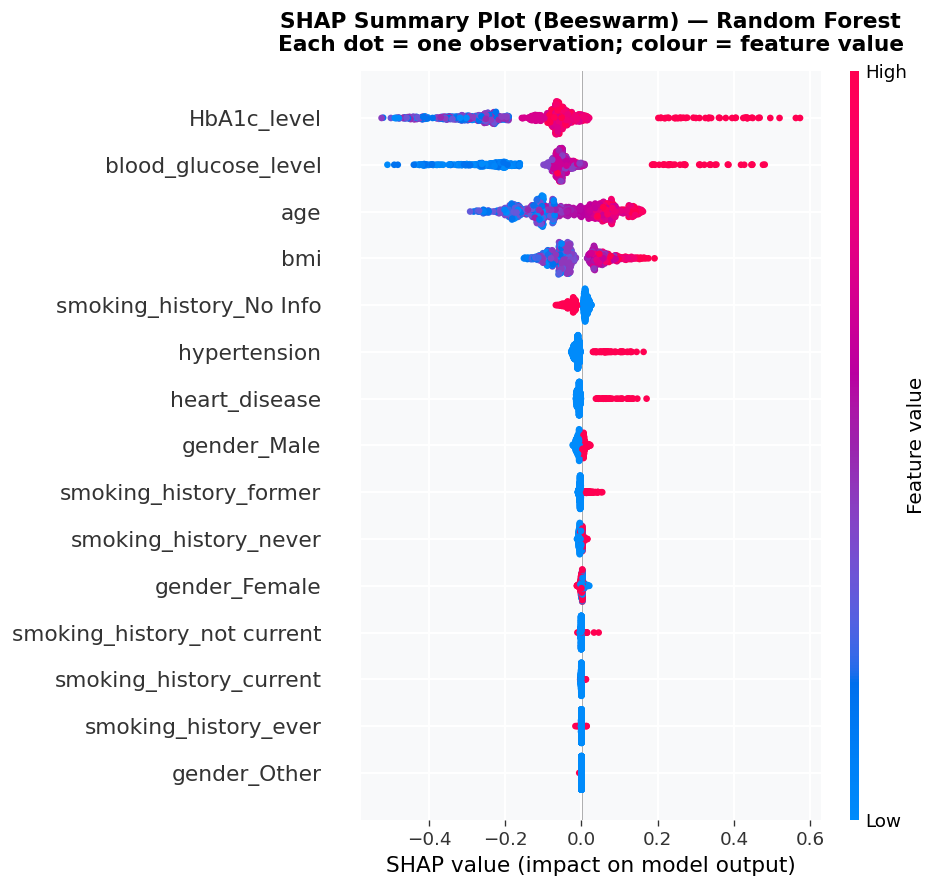

Saved: shap_summary_Random_Forest.png


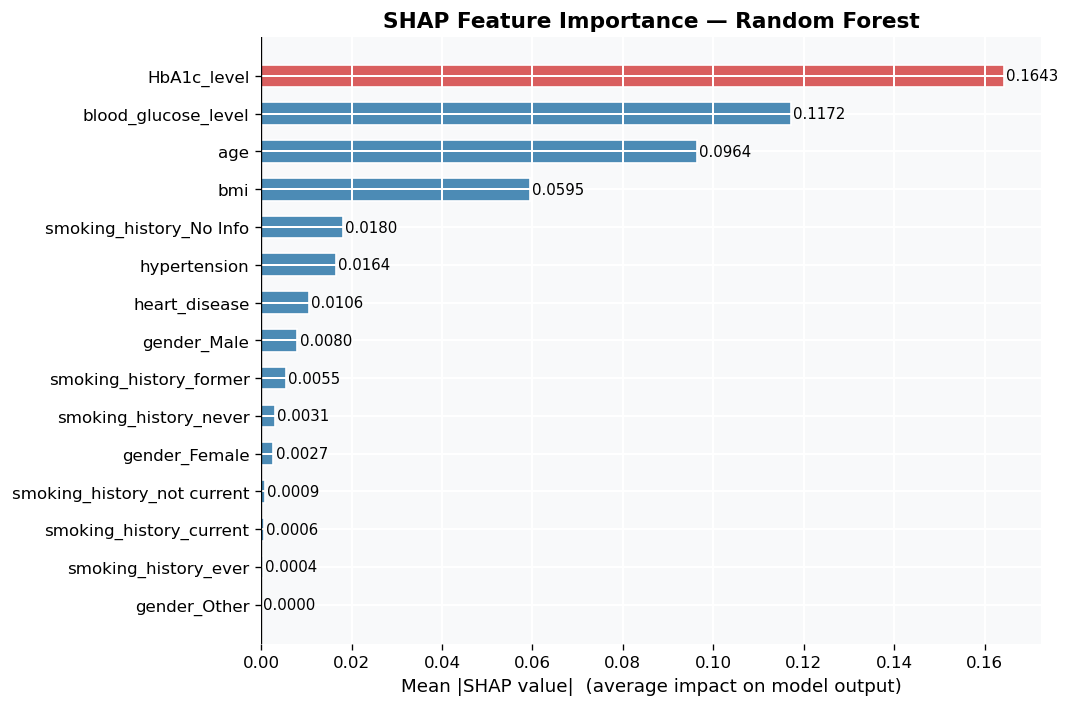

 Saved: shap_bar_Random_Forest.png

  Top 5 features (Random Forest):
    1. HbA1c_level              : mean|SHAP| = 0.1643
    2. blood_glucose_level      : mean|SHAP| = 0.1172
    3. age                      : mean|SHAP| = 0.0964
    4. bmi                      : mean|SHAP| = 0.0595
    5. smoking_history_No Info  : mean|SHAP| = 0.0180

Computing SHAP values for: XGBoost ...


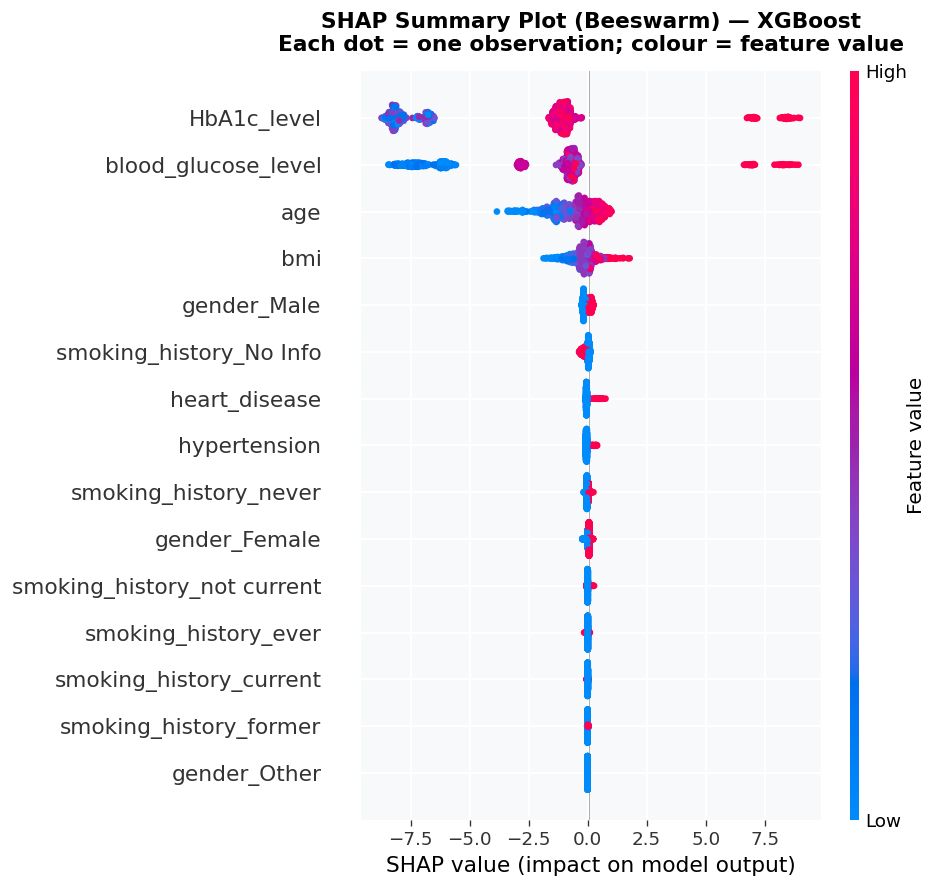

Saved: shap_summary_XGBoost.png


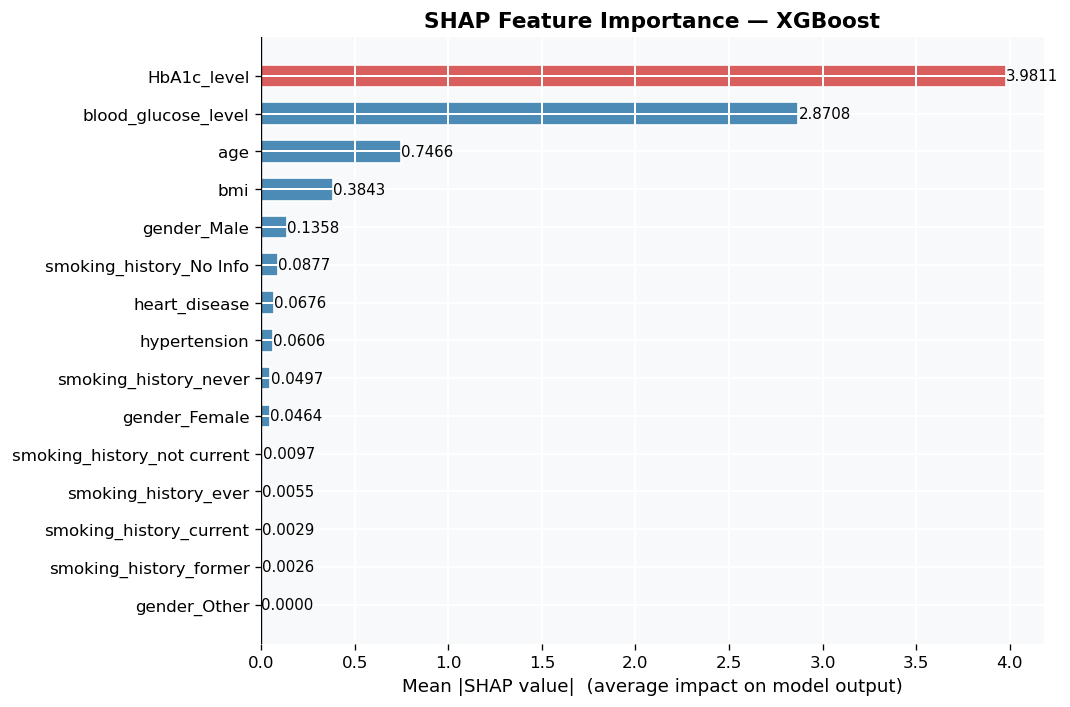

 Saved: shap_bar_XGBoost.png

  Top 5 features (XGBoost):
    1. HbA1c_level              : mean|SHAP| = 3.9811
    2. blood_glucose_level      : mean|SHAP| = 2.8708
    3. age                      : mean|SHAP| = 0.7466
    4. bmi                      : mean|SHAP| = 0.3843
    5. gender_Male              : mean|SHAP| = 0.1358

Computing SHAP values for: LightGBM ...


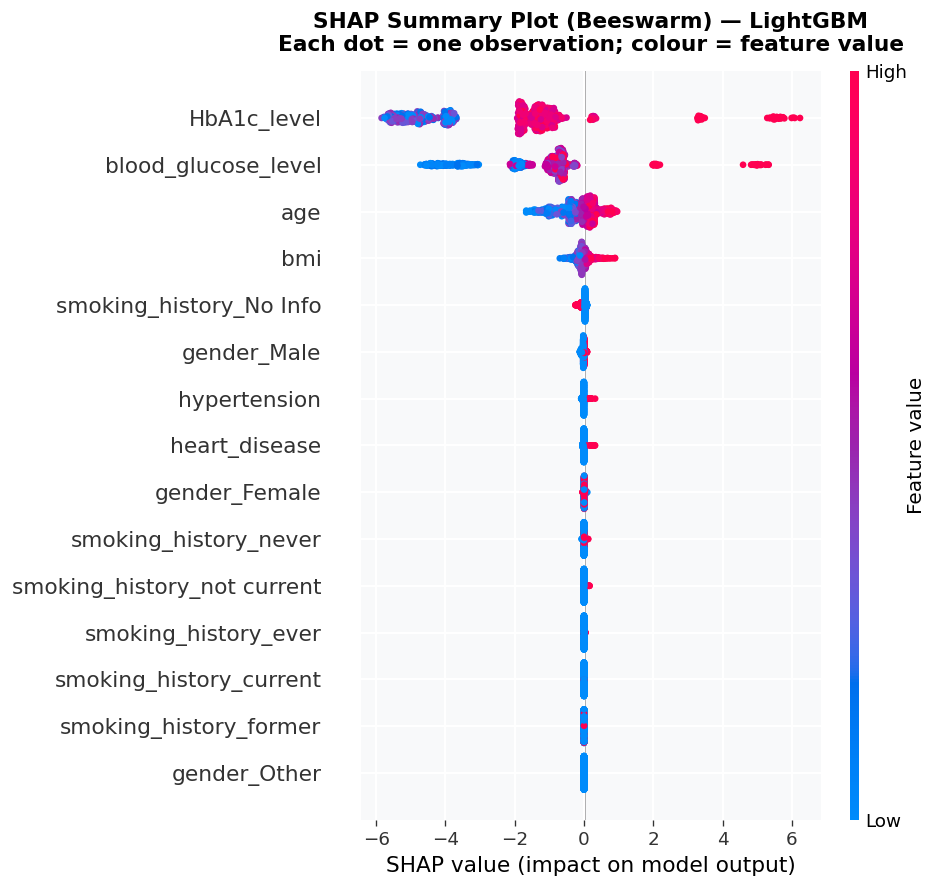

Saved: shap_summary_LightGBM.png


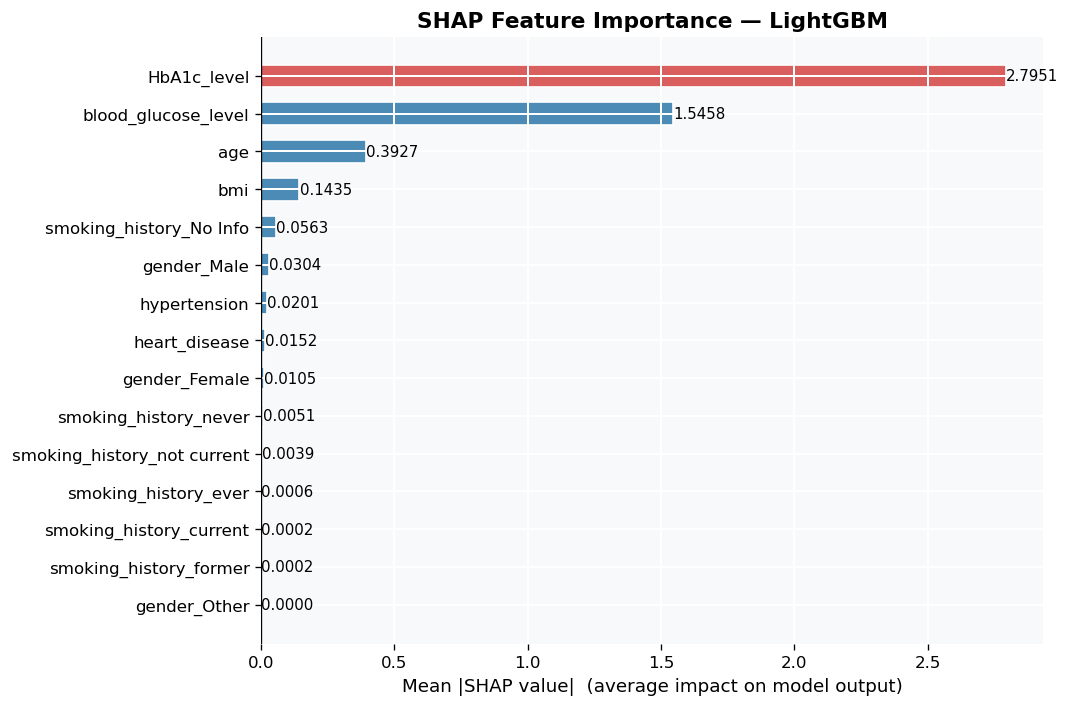

 Saved: shap_bar_LightGBM.png

  Top 5 features (LightGBM):
    1. HbA1c_level              : mean|SHAP| = 2.7951
    2. blood_glucose_level      : mean|SHAP| = 1.5458
    3. age                      : mean|SHAP| = 0.3927
    4. bmi                      : mean|SHAP| = 0.1435
    5. smoking_history_No Info  : mean|SHAP| = 0.0563


In [22]:
# SHAP Summary (Beeswarm) and Bar Plots for RF, XGBoost, LightGBM

SHAP_MODELS = ["Random Forest", "XGBoost", "LightGBM"]

for model_name in SHAP_MODELS:
    print(f"\nComputing SHAP values for: {model_name} ...")
    sv, X_df, feat_names = get_shap_values(model_name)
    mean_abs = np.abs(sv).mean(axis=0)

    # SHAP Beeswarm (Summary) Plot 
    fig = plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_df, feature_names=feat_names, show=False)
    plt.title(
        f"SHAP Summary Plot (Beeswarm) — {model_name}\n"
        "Each dot = one observation; colour = feature value",
        fontsize=13, fontweight="bold", pad=12
    )
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/shap_summary_{model_name.replace(' ','_')}.png",
                dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: shap_summary_{model_name.replace(' ','_')}.png")

    # SHAP Bar Plot (Mean |SHAP|) 
    feat_imp = (pd.Series(mean_abs, index=feat_names)
                  .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_bar = [C_RED if v == feat_imp.max() else C_BLUE
                  for v in feat_imp.values]
    bars = ax.barh(feat_imp.index, feat_imp.values,
                   color=colors_bar, edgecolor="white", height=0.6)
    for bar, val in zip(bars, feat_imp.values):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_xlabel("Mean |SHAP value|  (average impact on model output)", fontsize=11)
    ax.set_title(f"SHAP Feature Importance — {model_name}",
                 fontsize=13, fontweight="bold")
    ax.axvline(x=0, color="black", lw=0.8)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/shap_bar_{model_name.replace(' ','_')}.png",
                dpi=180, bbox_inches="tight")
    plt.show()
    print(f" Saved: shap_bar_{model_name.replace(' ','_')}.png")

    # Print top 5 features
    top5 = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False).head(5)
    print(f"\n  Top 5 features ({model_name}):")
    for rank, (feat, val) in enumerate(top5.items(), 1):
        print(f"    {rank}. {feat:<25}: mean|SHAP| = {val:.4f}")

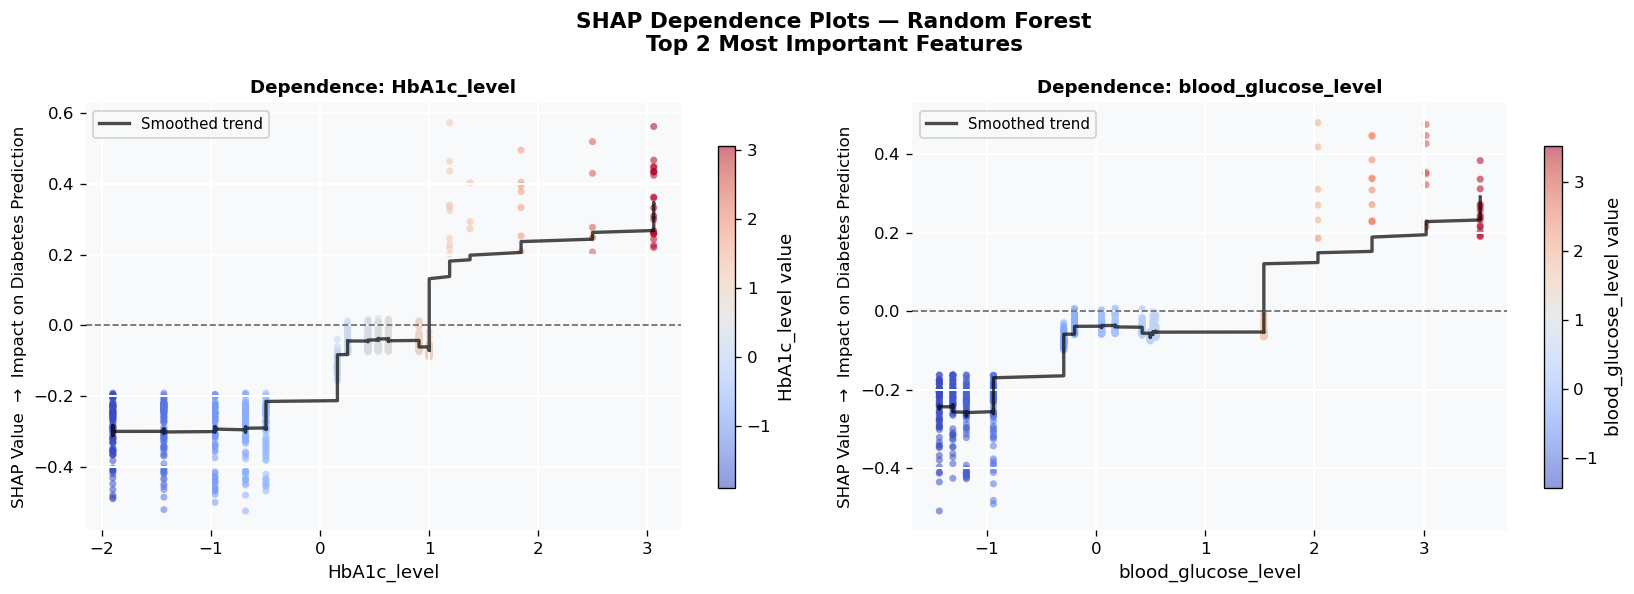

Saved: shap_dependence_Random_Forest.png


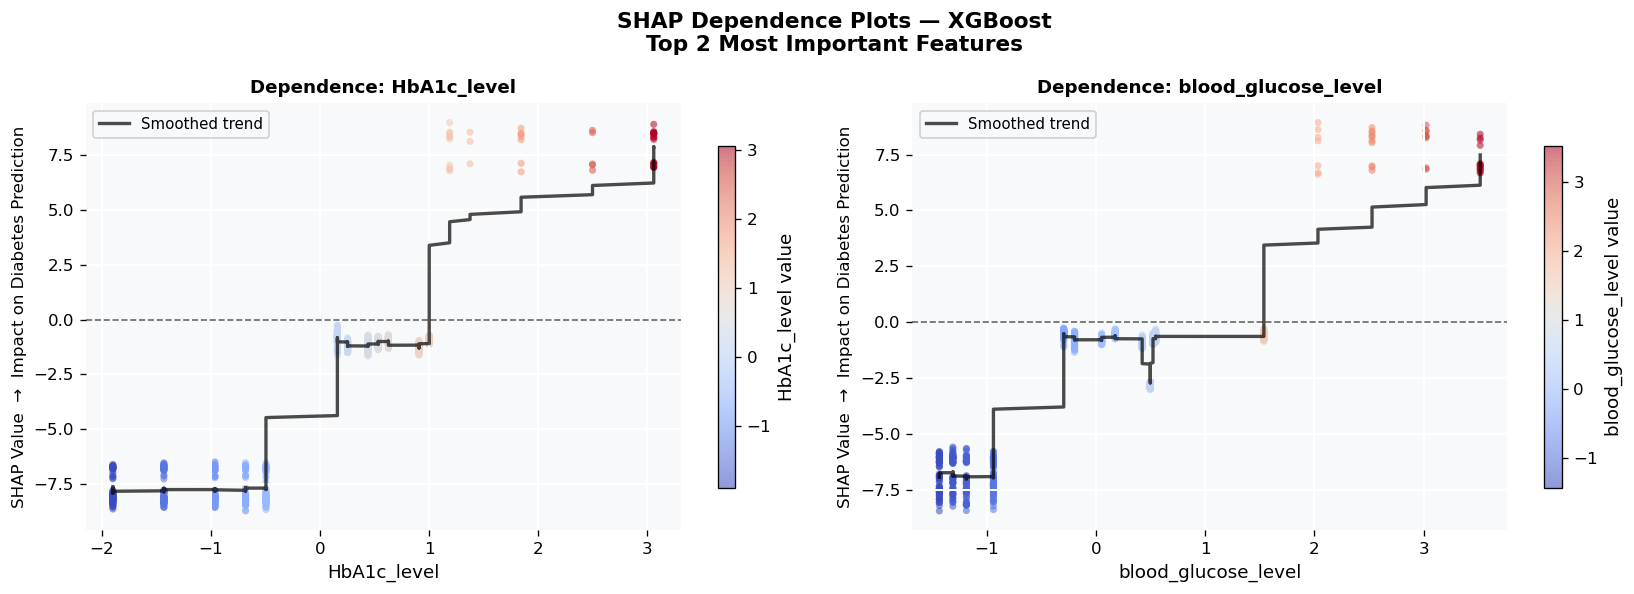

Saved: shap_dependence_XGBoost.png


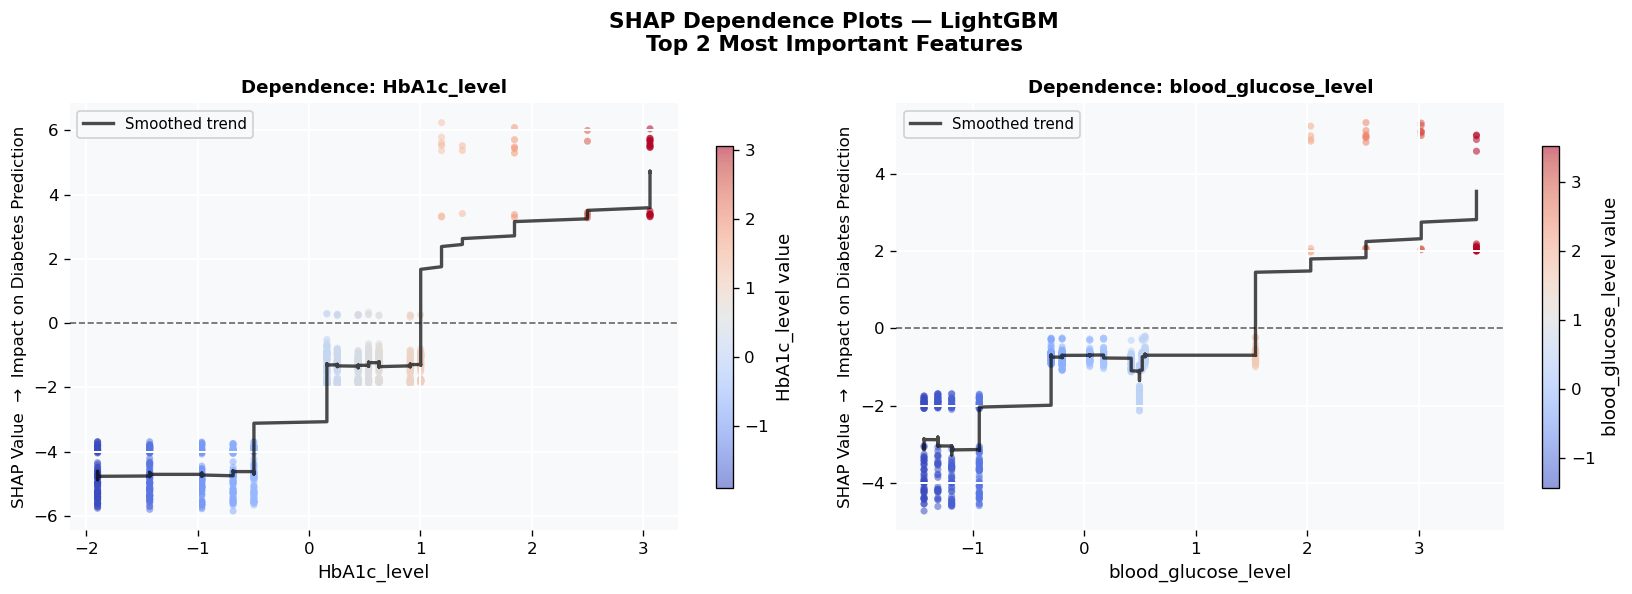

Saved: shap_dependence_LightGBM.png


In [23]:
# SHAP Dependence Plots: Top 2 Features per Tree Model
# Methodology: Dependence plots show how a single feature's value affects
#              its SHAP contribution, revealing non-linear dose-response relationships.

for model_name in SHAP_MODELS:
    sv, X_df, feat_names = get_shap_values(model_name)
    mean_abs = np.abs(sv).mean(axis=0)
    top2_idx = np.argsort(mean_abs)[-2:][::-1]
    top2     = [feat_names[i] for i in top2_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"SHAP Dependence Plots — {model_name}\n"
        "Top 2 Most Important Features",
        fontsize=13, fontweight="bold"
    )

    for ax, feat in zip(axes, top2):
        feat_idx  = feat_names.index(feat)
        feat_vals = X_df[feat].values
        shap_vals = sv[:, feat_idx]

        sc = ax.scatter(
            feat_vals, shap_vals,
            c        = feat_vals,
            cmap     = "coolwarm",
            alpha    = 0.55,
            s        = 18,
            edgecolors="none"
        )
        ax.axhline(0, color="black", lw=1.0, linestyle="--", alpha=0.6)

        # LOWESS smoothing line
        from scipy.ndimage import uniform_filter1d
        sort_idx = np.argsort(feat_vals)
        smooth_y = uniform_filter1d(shap_vals[sort_idx], size=80)
        ax.plot(feat_vals[sort_idx], smooth_y,
                color="black", lw=2.0, linestyle="-", alpha=0.7,
                label="Smoothed trend")

        plt.colorbar(sc, ax=ax, shrink=0.8, label=f"{feat} value")
        ax.set_xlabel(feat, fontsize=11)
        ax.set_ylabel("SHAP Value  →  Impact on Diabetes Prediction", fontsize=10)
        ax.set_title(f"Dependence: {feat}", fontweight="bold", fontsize=11)
        ax.legend(fontsize=9)

    plt.tight_layout()
    safe = model_name.replace(" ", "_")
    plt.savefig(f"{OUT_DIR}/shap_dependence_{safe}.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: shap_dependence_{safe}.png")

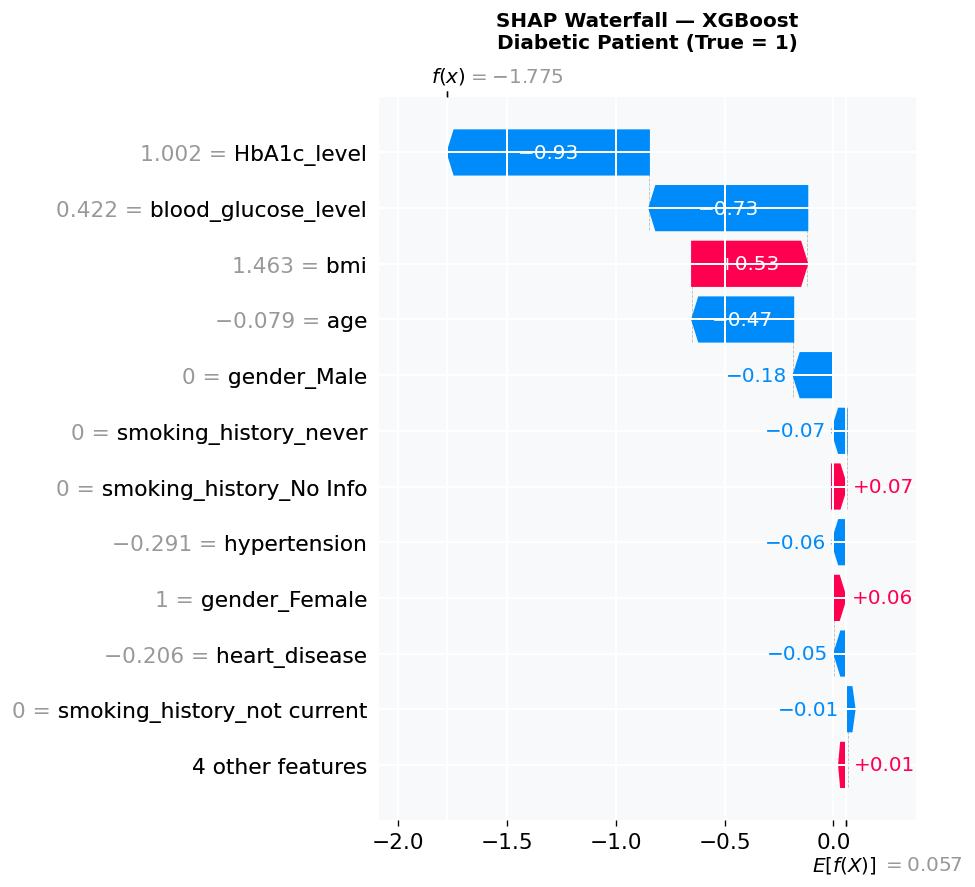

Saved: shap_waterfall_diabetic_XGBoost.png


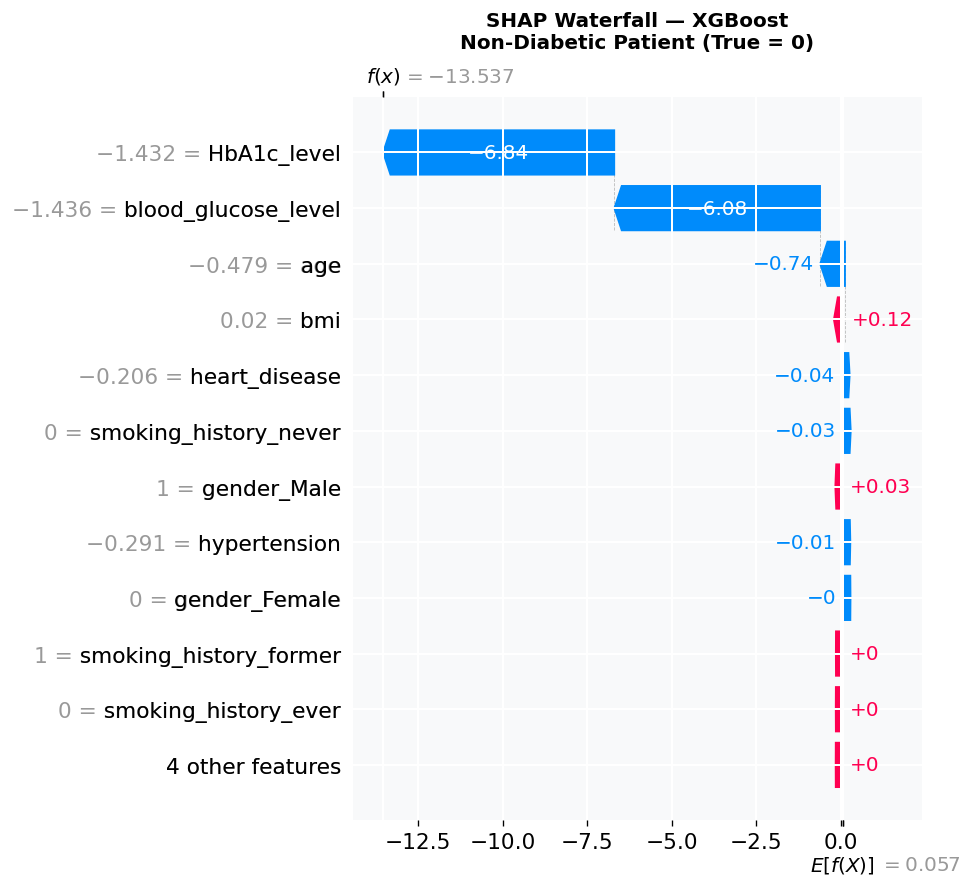

Saved: shap_waterfall_non-diabetic_XGBoost.png


In [24]:
# SHAP Waterfall Plot: Individual Prediction Explanation
# Methodology: Explains how each feature pushes a single prediction
#              above or below the baseline (expected) model output.
#              Useful for clinical decision support and patient-level interpretation.

EXPLAIN_MODEL = best_model_name    # explain the best-performing model

pipeline  = best_estimators[EXPLAIN_MODEL]
prep_step = pipeline.named_steps["prep"]
clf_step  = pipeline.named_steps["clf"]
feat_names = get_feature_names(prep_step)

X_explain_prep = prep_step.transform(X_shap)
X_explain_df   = pd.DataFrame(X_explain_prep, columns=feat_names)

explainer = shap.TreeExplainer(clf_step)
expl_obj  = explainer(X_explain_df)

# Pick one diabetic and one non-diabetic example
y_shap_true = y_test.loc[X_shap.index].values
diabetic_idx     = np.where(y_shap_true == 1)[0][0]
nondiabetic_idx  = np.where(y_shap_true == 0)[0][0]

for idx, label in [(diabetic_idx, "Diabetic Patient (True = 1)"),
                   (nondiabetic_idx, "Non-Diabetic Patient (True = 0)")]:

    # Handle 3-D shap values (RF) vs 2-D (boosting)
    if expl_obj.values.ndim == 3:
        import copy
        expl_single = copy.deepcopy(expl_obj[idx])
        expl_single.values = expl_obj.values[idx, :, 1]
        expl_single.base_values = expl_obj.base_values[idx, 1] \
            if hasattr(expl_obj.base_values, '__len__') \
            else expl_obj.base_values
    else:
        expl_single = expl_obj[idx]

    fig = plt.figure(figsize=(10, 6))
    shap.waterfall_plot(expl_single, max_display=12, show=False)
    plt.title(
        f"SHAP Waterfall — {EXPLAIN_MODEL}\n{label}",
        fontsize=12, fontweight="bold", pad=10
    )
    plt.tight_layout()
    fname = f"shap_waterfall_{label.split()[0].lower()}_{EXPLAIN_MODEL.replace(' ','_')}.png"
    plt.savefig(f"{OUT_DIR}/{fname}", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

In [25]:
# Final Model Interpretation
# Methodology: Identifies best model, explains performance, discusses clinical implications.
best_model = best_estimators[best_model_name]
best_row   = results_df.loc[best_model_name]
print("=" * 65)
print(f"  FINAL MODEL INTERPRETATION")
print("=" * 65)
print(f"""
    Best-Performing Model : {best_model_name}
  ─────────────────────────────────────────────────────────────
  ROC-AUC              : {best_row['ROC-AUC']:.4f}
  Accuracy             : {best_row['Accuracy']:.4f}
  Precision            : {best_row['Precision']:.4f}
  Recall (Sensitivity) : {best_row['Recall (Sensitivity)']:.4f}
  Specificity          : {best_row['Specificity']:.4f}
  F1-Score             : {best_row['F1-Score']:.4f}
""")

  FINAL MODEL INTERPRETATION

    Best-Performing Model : XGBoost
  ─────────────────────────────────────────────────────────────
  ROC-AUC              : 0.9761
  Accuracy             : 0.9682
  Precision            : 0.8934
  Recall (Sensitivity) : 0.7264
  Specificity          : 0.9916
  F1-Score             : 0.8013

